# DINOv2 寵物分類教學 / DINOv2 for Pet Classification

從 **直覺** → **解剖** → **應用** → **視覺證據** → **收束**，一份完整的 self-supervised ViT 教學。

## 我們會做什麼？

- 載入 Meta 預訓練的 **DINOv2-with-registers-small**（ViT-S/14, 21M 參數）
- 在 **Oxford-IIIT Pet**（37 種貓狗品種）做 **kNN 分類**與 **Linear Probe**
- 視覺化 DINO 招牌的 **attention map 自動 segmentation**
- 對比有 / 無 **register tokens** 的差異

## 教學結構

| Part | 章節 | 目的 |
|---|---|---|
| **I. 直覺** | Ch 1–3 | 理解 DINO 是什麼、為何重要 |
| **II. 解剖** | Ch 4–5 | 在「用」之前，先「看懂」模型內部 |
| **III. 應用** | Ch 6–10 | 用 DINOv2 做下游分類，量化 feature 品質 |
| **IV. 證據** | Ch 11–12 | 視覺化 attention map，印證 Part I 直覺 |
| **V. 收束** | Ch 13 | 總結、延伸方向 |

---
# Part I — 直覺 / Intuition

> 在動手寫 code 之前，先理解 **DINO 在做什麼**、**為什麼這樣設計**。沒有這層理解，後面看到 attention map 自動畫出貓的輪廓你會嚇到不知道為什麼。

## 第 1 章：DINO 在解什麼問題？

### Self-Supervised Learning (SSL) 的動機

在 vision 領域，**標註資料昂貴**：
- ImageNet 有 1,400 萬張標註圖
- 但網路上有 **數十億張** 沒標註的圖
- SSL 的問題意識：「能不能不用標籤，也讓模型學到好的視覺特徵？」

### 圖像 SSL 為何難？

NLP 有天然的 SSL 任務：「猜下一個 token」。
但圖像沒有這樣明確的「next」結構，所以歷史上嘗試過很多方法：

| 方法 | 思路 | 問題 |
|---|---|---|
| Autoencoder | 重建像素 | 強迫保留低階紋理，learnt features 不夠抽象 |
| Rotation prediction | 預測圖被旋轉幾度 | 任務太簡單，feature 不夠強 |
| Contrastive (SimCLR/MoCo) | 同張圖的不同 augmentation 拉近、其他推遠 | 需要 large negative batch、靠 batch size 撐效能 |
| **DINO (2021)** | **Self-distillation：student 學 teacher 的輸出** | **不需要 negatives、不需要標籤、attention 自動 segment 物體** |

### DINO 的一句話定位

> **「不用標籤的 ViT 預訓練，得到的 features 強到 frozen 後直接做分類就贏；更神奇的是 attention map 會自動分割出物體輪廓。」**

這份教學會親自驗證最後這兩個 claim。

## 第 2 章：DINO 演算法的核心思想

> 我們是用 pretrained model，**不在這章寫 training code**。但理解原理才能解釋後面為什麼 attention map 會自動 segment 物體。

### 兩個關鍵組件

**(1) Student-Teacher 架構**

兩個結構一模一樣的 ViT：
- **Student** 用 SGD/AdamW 更新
- **Teacher** 不直接訓練，而是用 student 參數的 **指數移動平均 (EMA)**：
  $$\theta_{teacher} \leftarrow \tau \cdot \theta_{teacher} + (1-\tau) \cdot \theta_{student}$$
- Teacher 是「比較慢、比較穩定」的 student

**為什麼 teacher 要用 EMA，不直接複製 student？**

因為 student 是「對著 teacher 的輸出學」——teacher 就是它的**學習目標**。如果 teacher 每一步都＝當下的 student，那目標會跟著 student 一起劇烈跳動，**等於追自己的尾巴**，訓練極不穩定。EMA 讓 teacher 變成 student 的「**慢動作平均**」：方向一致、但抖動被抹平，給 student 一個穩定又稍微領先的靶。

> 這跟 RL 裡 DQN 的 **target network** 是同一個招數：用一個更新較慢的網路當目標，避免「目標和被訓練的網路一起亂動」。實務上 DINO 的 teacher 在訓練中途的表現甚至**比 student 還好**，所以拿它當靶很合理。

**(2) Multi-crop 策略**

每張圖隨機切出：
- **2 個 global crop**（大區域，~224×224）
- **多個 local crop**（小區域，~96×96）

規則：
- **Teacher 只看 global crop**
- **Student 看所有 crop**
- 訓練目標：student 對 local crop 的輸出 ≈ teacher 對 global crop 的輸出
- 直覺：「**看到局部要能推測出整體**」→ 強迫模型學到語意而非像素細節

### 為什麼不會 collapse？

**先講什麼叫 collapse。** Student 的目標是讓自己的輸出去「對齊」teacher 的輸出。這裡有個作弊解能讓 loss 直接歸零：**不管輸入什麼圖，兩邊都吐出同一個向量**。這樣 loss=0，但模型什麼都沒學到——這就是 collapse（trivial solution）。

崩潰其實有**兩種長相**，DINO 用**兩招、各擋一種**：

| Collapse 模式 | 長相 | 對應解藥 |
|---|---|---|
| **① 某一維獨大** | teacher 輸出永遠偏向同一維（像永遠猜「A」） | **Centering** |
| **② 攤平成均勻分布** | teacher 對每維都給差不多的機率（等於沒資訊） | **Sharpening** |

- **Centering（防①）**：teacher 的輸出 logits 先減掉一個**滑動平均中心** $c$ 再做 softmax。$c$ 會追蹤「哪一維最近老是偏高」並把它減掉 → 沒有任何一維能長期獨大。
- **Sharpening（防②）**：teacher 用**較低的 softmax temperature**，把分布壓尖。溫度越低，輸出越「敢挑一個答案」，而不是攤成平均。

**關鍵在這兩招方向相反、互相拉扯：**

```
Centering   →  把分布推向「均勻」(壓掉獨大維)  ┐
                                               ├─ 兩力平衡 → 不偏不倚、又有資訊量
Sharpening  →  把分布推向「尖銳」(逼它表態)    ┘
```

只用 centering 會滑向模式②（太均勻）；只用 sharpening 會滑向模式①（太尖、某維獨大）。**兩個一起用，剛好卡在中間**——既不讓單一維獨大，又保持「每張圖的輸出確實不一樣、帶有資訊」。這就是 DINO 不需要 negative sample 也不會崩潰的核心設計。

下方用一張概念圖把整個流程串起來。


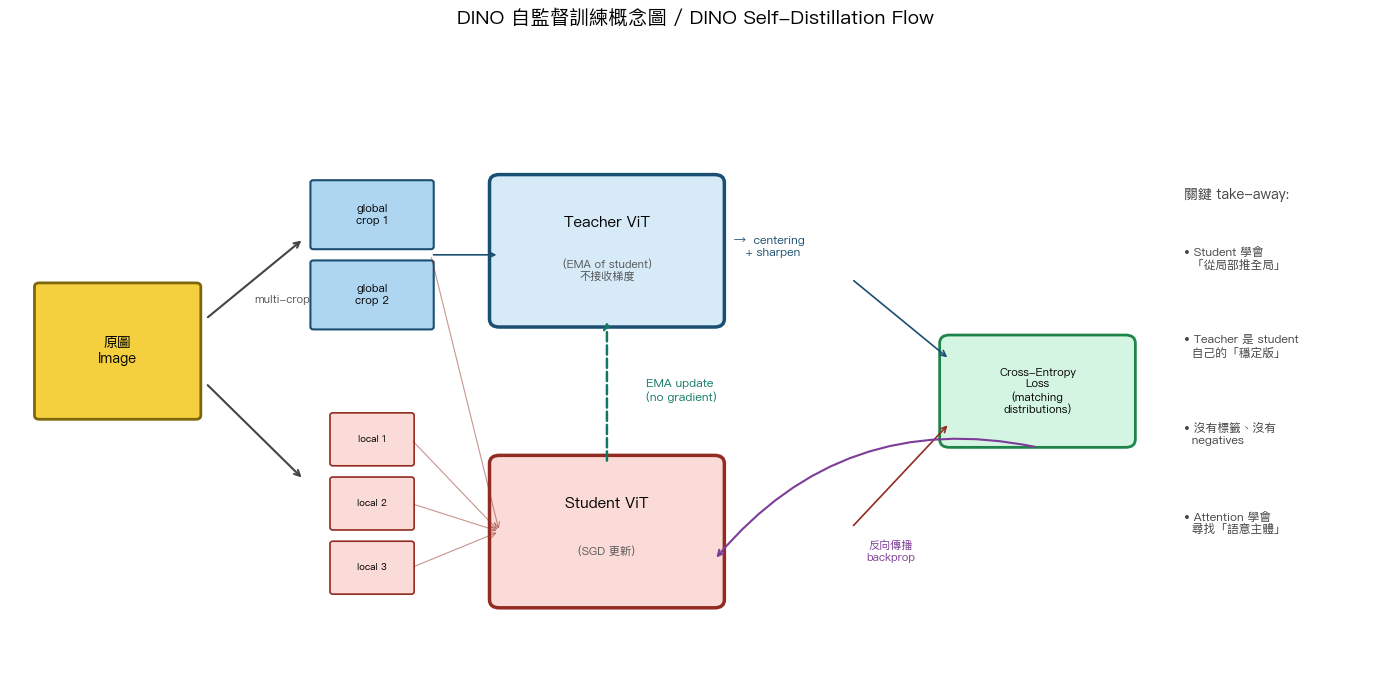

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import numpy as np

# 自動偵測系統可用的中文字型（跨平台，且不會洗 findfont 警告）
from matplotlib import font_manager as _fm
_cjk = [f for f in ['Microsoft JhengHei', 'PingFang HK', 'PingFang TC', 'Heiti TC',
                    'Arial Unicode MS', 'Noto Sans CJK TC', 'Noto Sans CJK SC', 'WenQuanYi Zen Hei']
        if f in {x.name for x in _fm.fontManager.ttflist}] + ['DejaVu Sans']
plt.rcParams['font.sans-serif'] = _cjk
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14); ax.set_ylim(0, 8); ax.axis('off')
ax.set_title('DINO 自監督訓練概念圖 / DINO Self-Distillation Flow', fontsize=14, pad=10)

# 原始圖像
img_box = mpatches.FancyBboxPatch((0.3, 3.3), 1.6, 1.6, boxstyle='round,pad=0.05',
                                   facecolor='#F4D03F', edgecolor='#7D6608', linewidth=2)
ax.add_patch(img_box)
ax.text(1.1, 4.1, '原圖\nImage', ha='center', va='center', fontsize=10, fontweight='bold')

# Multi-crop 區
ax.annotate('', xy=(3.0, 5.5), xytext=(2.0, 4.5),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='#444'))
ax.annotate('', xy=(3.0, 2.5), xytext=(2.0, 3.7),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='#444'))
ax.text(2.5, 4.7, 'multi-crop', fontsize=8, color='#555', style='italic')

# Global crops (teacher 看)
for i, y in enumerate([5.8, 4.8]):
    box = mpatches.FancyBboxPatch((3.1, y-0.4), 1.2, 0.8, boxstyle='round,pad=0.03',
                                   facecolor='#AED6F1', edgecolor='#1B4F72', linewidth=1.5)
    ax.add_patch(box)
    ax.text(3.7, y, f'global\ncrop {i+1}', ha='center', va='center', fontsize=8)

# Local crops (student 看更多)
for i, y in enumerate([3.0, 2.2, 1.4]):
    box = mpatches.FancyBboxPatch((3.3, y-0.3), 0.8, 0.6, boxstyle='round,pad=0.03',
                                   facecolor='#FADBD8', edgecolor='#922B21', linewidth=1.2)
    ax.add_patch(box)
    ax.text(3.7, y, f'local {i+1}', ha='center', va='center', fontsize=7)

# Teacher 模型框
teacher_box = mpatches.FancyBboxPatch((5.0, 4.5), 2.2, 1.7, boxstyle='round,pad=0.1',
                                       facecolor='#D6EAF8', edgecolor='#1B4F72', linewidth=2.5)
ax.add_patch(teacher_box)
ax.text(6.1, 5.7, 'Teacher ViT', ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(6.1, 5.1, '(EMA of student)\n不接收梯度', ha='center', va='center', fontsize=8, color='#555')

# Student 模型框
student_box = mpatches.FancyBboxPatch((5.0, 1.0), 2.2, 1.7, boxstyle='round,pad=0.1',
                                       facecolor='#FADBD8', edgecolor='#922B21', linewidth=2.5)
ax.add_patch(student_box)
ax.text(6.1, 2.2, 'Student ViT', ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(6.1, 1.6, '(SGD 更新)', ha='center', va='center', fontsize=8, color='#555')

# Crops → models 連接
ax.annotate('', xy=(5.0, 5.3), xytext=(4.3, 5.3), arrowprops=dict(arrowstyle='->', lw=1.2, color='#1B4F72'))
for y in [3.0, 2.2, 1.4]:
    ax.annotate('', xy=(5.0, 1.85), xytext=(4.1, y), arrowprops=dict(arrowstyle='->', lw=0.8, color='#922B21', alpha=0.5))
ax.annotate('', xy=(5.0, 1.85), xytext=(4.3, 5.3), arrowprops=dict(arrowstyle='->', lw=0.8, color='#922B21', alpha=0.5))

# Centering + Sharpening on teacher output
ax.text(7.4, 5.4, '→  centering\n   + sharpen', ha='left', va='center', fontsize=8.5, color='#1B4F72')

# Loss
loss_box = mpatches.FancyBboxPatch((9.6, 3.0), 1.8, 1.2, boxstyle='round,pad=0.1',
                                    facecolor='#D5F5E3', edgecolor='#1E8449', linewidth=2)
ax.add_patch(loss_box)
ax.text(10.5, 3.6, 'Cross-Entropy\nLoss\n(matching\ndistributions)', ha='center', va='center', fontsize=8)

# Outputs → loss
ax.annotate('', xy=(9.6, 4.0), xytext=(8.6, 5.0), arrowprops=dict(arrowstyle='->', lw=1.2, color='#1B4F72'))
ax.annotate('', xy=(9.6, 3.2), xytext=(8.6, 1.9), arrowprops=dict(arrowstyle='->', lw=1.2, color='#922B21'))

# Gradient back to student
ax.annotate('', xy=(7.2, 1.5), xytext=(10.5, 2.9),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='#7D3C98', connectionstyle='arc3,rad=0.3'))
ax.text(9.0, 1.6, '反向傳播\nbackprop', ha='center', va='center', fontsize=8, color='#7D3C98')

# EMA update
ax.annotate('', xy=(6.1, 4.5), xytext=(6.1, 2.7),
            arrowprops=dict(arrowstyle='->', lw=1.8, color='#117864', linestyle='dashed'))
ax.text(6.5, 3.6, 'EMA update\n(no gradient)', ha='left', va='center', fontsize=8.5, color='#117864', style='italic')

# Right side note
ax.text(12.0, 6.0, '關鍵 take-away:', fontsize=10, fontweight='bold', color='#444')
ax.text(12.0, 5.4, '• Student 學會\n  「從局部推全局」', fontsize=8.5, color='#444', va='top')
ax.text(12.0, 4.3, '• Teacher 是 student\n  自己的「穩定版」', fontsize=8.5, color='#444', va='top')
ax.text(12.0, 3.2, '• 沒有標籤、沒有\n  negatives', fontsize=8.5, color='#444', va='top')
ax.text(12.0, 2.1, '• Attention 學會\n  尋找「語意主體」', fontsize=8.5, color='#444', va='top')

plt.tight_layout(); plt.show()

## 第 3 章：DINOv1 → v2 → v3 的演進

| 維度 | DINOv1 (2021) | **DINOv2 (2023)** ⭐ | DINOv3 (2025) |
|---|---|---|---|
| Backbone | ViT-S/16, ViT-B/16 | ViT-S/14 ~ ViT-g/14 | ViT-S/16 ~ ViT-7B/16, ConvNeXt |
| 預訓練資料 | ImageNet (1.4M) | LVD-142M（自動 curated 142M） | LVD-1.6B |
| Patch size | 16 | **14**（更細） | 16 |
| 訓練技巧 | 原版 self-distillation | + iBOT（masked patch prediction）、KoLeo regularizer | + Gram anchoring、gated attention |
| Register tokens | ❌ | ✅（with-registers 版本） | ✅ |

### 為什麼 DINOv2 需要 register tokens？

論文 ["Vision Transformers Need Registers" (Darcet et al., 2023)](https://arxiv.org/abs/2309.16588) 發現：

- 訓練好的 DINOv2 attention map 上偶爾出現 **高激活的雜訊點**（artifact）
- 原因：模型沒有「臨時計算空間」，被迫把全域計算暫存到不重要的 patch token 上 → 那些 patch 的 attention 變得異常
- 解法：加 4 個 **可學習的 register token** 當作 scratchpad
- 結果：attention map 變乾淨、下游任務也微幅提升

**Part IV 會親眼看到這個差異。**

### 我們的選擇：`facebook/dinov2-with-registers-small`

- 21M 參數（ViT-S/14），在 MPS / CPU 上跑得動
- 帶 register tokens 的最新最佳實踐版本
- embedding dim = 384，剛好夠做下游分類

---
# Part II — 解剖 / Anatomy

> 在「用」之前先「看懂」。很多教學跳過這步直接呼叫 model，讀者永遠不知道 `outputs.last_hidden_state` 裡每個 token 是什麼。我們拆得清清楚楚再往下走。

## 第 4 章：載入 DINOv2 並拆解結構

我們用 HuggingFace `transformers` 載入模型——比 `torch.hub` 更穩定、有 register-token 版本。

依賴已在 `pyproject.toml` 宣告（`transformers` / `torchvision` / `scikit-learn`），用 `uv sync` 安裝即可。


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from transformers import AutoModel, AutoImageProcessor
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 自動偵測系統可用的中文字型（跨平台，且不會洗 findfont 警告）
from matplotlib import font_manager as _fm
_cjk = [f for f in ['Microsoft JhengHei', 'PingFang HK', 'PingFang TC', 'Heiti TC',
                    'Arial Unicode MS', 'Noto Sans CJK TC', 'Noto Sans CJK SC', 'WenQuanYi Zen Hei']
        if f in {x.name for x in _fm.fontManager.ttflist}] + ['DejaVu Sans']
plt.rcParams['font.sans-serif'] = _cjk
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# 自動偵測裝置 / Auto-detect device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'使用裝置 / Device: {DEVICE}')

# 固定亂數種子 / Fix random seeds for reproducibility
# 影響：linear probe 的 nn.Linear 初始化、torch.randperm 洗牌、np 抽樣——
# 沒固定的話每次 run 的 probe 準確率會小幅跳動。
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

使用裝置 / Device: mps


In [8]:
MODEL_NAME = 'facebook/dinov2-with-registers-small'

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
# 注意：attn_implementation='eager' 是為了 Part IV 能拿到 attention weights
# 預設的 SDPA 較快但不回傳 attention（transformers >=4.4x 預設用 SDPA）
model     = AutoModel.from_pretrained(MODEL_NAME, attn_implementation='eager').to(DEVICE).eval()

# 統計參數量
n_params = sum(p.numel() for p in model.parameters())
print(f'模型: {MODEL_NAME}')
print(f'參數量 / Params: {n_params/1e6:.2f}M')
print(f'隱藏維度 / Hidden dim: {model.config.hidden_size}')
print(f'Patch size: {model.config.patch_size}')
print(f'Transformer 層數 / # layers: {model.config.num_hidden_layers}')
print(f'Attention heads: {model.config.num_attention_heads}')
print(f'Register tokens: {model.config.num_register_tokens}')
print(f'Attention implementation: {model.config._attn_implementation}')
print(f'\n預訓練時的影像尺寸 / Pretrain image size: {model.config.image_size}')

模型: facebook/dinov2-with-registers-small
參數量 / Params: 22.06M
隱藏維度 / Hidden dim: 384
Patch size: 14
Transformer 層數 / # layers: 12
Attention heads: 6
Register tokens: 4
Attention implementation: eager

預訓練時的影像尺寸 / Pretrain image size: 518


In [9]:
# 印出模型骨架（摺疊顯示）/ Print model skeleton
print('── DINOv2-with-registers-small 結構 ──\n')
print('Embeddings (patch projection + CLS + 4 registers + pos embed):')
for name, mod in model.embeddings.named_children():
    print(f'  {name:25s} {mod.__class__.__name__}')

print(f'\nEncoder: {len(model.encoder.layer)} × Transformer Block')
block0 = model.encoder.layer[0]
for name, _ in block0.named_children():
    print(f'  Block.{name}')

print('\nLayernorm (最終輸出前) / Final LayerNorm:')
print(f'  {model.layernorm}')

# ── torchinfo：逐層輸出 shape + 參數量總表 ──
# ⚠️ 常見的 torchsummary 對 HF 模型會壞：DINOv2 的 attention 子模組回傳
#    (輸出, None)，torchsummary 讀 None.size() 直接 crash，且崩潰後還會留下髒 hook。
#    改用其官方後繼者 torchinfo（uv add torchinfo），能正確處理，
#    順便量化驗證上面手列結構的參數量（≈22M）。
# ⚠️⚠️ torchinfo 的隱藏雷：summary() 會實跑一次 forward，且預設把 model 搬到
#    「cuda→否則 cpu」(它不看 model 原本在哪)，跑完還「不搬回去」。在 Mac(mps) 上
#    這會把 model 偷偷變成 cpu，害後面 forward cell 報
#    "Input type (MPSFloatType) and weight type (torch.FloatTensor)"。
#    解法：明確傳 device=（model 當前 device），並在結束後搬回原 device。
from torchinfo import summary

_dev = next(model.parameters()).device    # 記住 model 原本的 device（mps/cuda/cpu）
print('\n── torchinfo summary（逐層輸出 shape + 參數量）──')
summary(
    model,
    input_size=(1, 3, 224, 224),          # 比照預訓練輸入；torchinfo 會實跑一次 forward
    col_names=['output_size', 'num_params'],
    depth=2,                              # 展開到 Embeddings / Encoder / LayerNorm 這層
    row_settings=['var_names'],           # 同時顯示屬性名（embeddings / encoder / layernorm）
    verbose=1,
    device=_dev,                          # ← 明確指定，別讓 torchinfo 把 model 搬去 cpu
);                                        # 結尾分號：避免 Jupyter 再自動 repr 印一次（變兩份）
model.to(_dev)                            # ← 保險：跑完搬回原 device，確保後續 forward 不會 device 不一致

── DINOv2-with-registers-small 結構 ──

Embeddings (patch projection + CLS + 4 registers + pos embed):
  patch_embeddings          Dinov2WithRegistersPatchEmbeddings
  dropout                   Dropout

Encoder: 12 × Transformer Block
  Block.norm1
  Block.attention
  Block.layer_scale1
  Block.drop_path
  Block.norm2
  Block.mlp
  Block.layer_scale2

Layernorm (最終輸出前) / Final LayerNorm:
  LayerNorm((384,), eps=1e-06, elementwise_affine=True)

── torchinfo summary（逐層輸出 shape + 參數量）──
Layer (type (var_name))                                                Output Shape              Param #
Dinov2WithRegistersModel (Dinov2WithRegistersModel)                    [1, 384]                  --
├─Dinov2WithRegistersEmbeddings (embeddings)                           [1, 261, 384]             528,384
│    └─Dinov2WithRegistersPatchEmbeddings (patch_embeddings)           [1, 256, 384]             226,176
│    └─Dropout (dropout)                                               [1, 261, 384]             -

Dinov2WithRegistersModel(
  (embeddings): Dinov2WithRegistersEmbeddings(
    (patch_embeddings): Dinov2WithRegistersPatchEmbeddings(
      (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2WithRegistersEncoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2WithRegistersLayer(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2WithRegistersAttention(
          (attention): Dinov2WithRegistersSelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
          )
          (output): Dinov2WithRegistersSelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_s

**讀懂這個結構：**

- `embeddings` 把 `224×224×3` 影像切成 `16×16=256` 個 patch，每塊投影到 384 維，前面再串上 `[CLS]` 和 4 個 register tokens → 共 **261 個 token**
- `encoder` 是 12 層 Transformer Block（每層含 multi-head attention + MLP + LayerNorm）
- 最終輸出的 `last_hidden_state` shape 為 `(batch, 261, 384)`

下一章我們會跑一張圖、把 261 個 token 看清楚。

### 等等——`print()` 怎麼沒看到 CLS、registers、positional embedding？

上面的輸出裡 `embeddings` 只顯示了 `patch_embeddings` 和 `dropout`，但根據第 2 章 / 第 4 章的說明，這個模組應該還要有：

- `[CLS]` token
- 4 個 register tokens
- positional embeddings
- mask token（DINOv2 預訓練用）

**它們確實存在**——只是 PyTorch 的 `print(model)` / `named_children()` **只列 `nn.Module`，不列 `nn.Parameter`**。CLS / registers / pos_embed 是純張量參數，沒有自己的 `forward()`，所以不算 Module。

PyTorch 把模型裡的東西分成兩類：

| 種類 | 是什麼 | 例子 | `print(model)` 看得到？ |
|---|---|---|---|
| `nn.Module` | 有 `forward()` 的計算單元 | `Conv2d`, `Linear`, `LayerNorm`, `Dropout` | ✅ |
| `nn.Parameter` | 可學習張量（會被 optimizer 收集） | `cls_token`, `pos_embed` | ❌ |
| `forward()` 裡的 op | `+`, `torch.cat`, `reshape` … | 把 CLS 拼到序列前面 | ❌ |

下面我們**親自把它們列出來**：

In [10]:
# 列出 embeddings 模組裡的「parameters」（不是 submodules）
emb = model.embeddings

print('── nn.Parameter（張量參數，print(model) 看不到） ──')
for name, p in emb.named_parameters(recurse=False):
    print(f'  {name:22s} shape={tuple(p.shape)}  requires_grad={p.requires_grad}')

print('\n── nn.Module（子模組，print(model) 看得到） ──')
for name, m in emb.named_children():
    print(f'  {name:22s} {m.__class__.__name__}')

# 再看 patch_embeddings 裡面有什麼（就一個 Conv2d）
print('\n── patch_embeddings 的細節 ──')
print(f'  projection: {emb.patch_embeddings.projection}')

── nn.Parameter（張量參數，print(model) 看不到） ──
  cls_token              shape=(1, 1, 384)  requires_grad=True
  mask_token             shape=(1, 384)  requires_grad=True
  register_tokens        shape=(1, 4, 384)  requires_grad=True
  position_embeddings    shape=(1, 1370, 384)  requires_grad=True

── nn.Module（子模組，print(model) 看得到） ──
  patch_embeddings       Dinov2WithRegistersPatchEmbeddings
  dropout                Dropout

── patch_embeddings 的細節 ──
  projection: Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))


### 那「加 CLS」「加 pos embed」「插 registers」這些步驟在哪？

**在 `forward()` 裡。** 它們不是模組、不是參數，而是**運算**——`torch.cat`、`+` 這種一行就完成的事，所以 `print(model)` 不會列。

Embeddings 的 `forward()` 實際做了什麼（看 source code `transformers/models/dinov2_with_registers/modeling_dinov2_with_registers.py` line 146–170）：

```python
def forward(self, pixel_values, bool_masked_pos=None):
    # ① patch projection: (B, 3, 224, 224) → (B, 256, 384)
    embeddings = self.patch_embeddings(pixel_values)

    # ② （訓練時才會走）把指定位置的 patch 換成 mask_token
    if bool_masked_pos is not None:
        embeddings = torch.where(bool_masked_pos.unsqueeze(-1),
                                 self.mask_token, embeddings)

    # ③ 在 sequence 最前面塞 CLS → (B, 257, 384)
    cls_tokens = self.cls_token.expand(batch_size, -1, -1)
    embeddings = torch.cat((cls_tokens, embeddings), dim=1)

    # ④ 加 positional embedding（每個 token 對應一個位置向量）
    embeddings = embeddings + self.interpolate_pos_encoding(embeddings, h, w)

    # ⑤ 在 CLS 後面、patches 前面插入 4 個 register → (B, 261, 384)
    embeddings = torch.cat(
        (embeddings[:, :1],                            # CLS
         self.register_tokens.expand(B, -1, -1),       # registers
         embeddings[:, 1:]),                           # patches
        dim=1)

    embeddings = self.dropout(embeddings)
    return embeddings
```

**順序的兩個小重點：**
1. **Pos embed 是先加在「CLS + patches」上、registers 才插入**——因為 registers 沒有空間意義，不需要 positional encoding。
2. Pos embed 的形狀是 `(1, 257, 384)`（CLS + 256 patches），不是 261；registers 走的是「無 pos」的路線。

**最終 token sequence (261)：**
```
[CLS] [R1] [R2] [R3] [R4] [p1] [p2] [p3] ... [p256]
  ↑    ↑——4 個 register——↑   ↑——256 個 image patch——↑
  有 pos    沒有 pos              有 pos
```

下一章我們會把這 261 個 token 跑出來、印 shape 驗證。

## 第 5 章：一張圖的完整 Forward Pass

用一張測試圖（隨便一張寵物圖），把整條 pipeline 從輸入跑到輸出，**看清楚每個 tensor shape 在說什麼**。

樣本標籤 / Label: Abyssinian
原圖尺寸 / Image size: (394, 500)


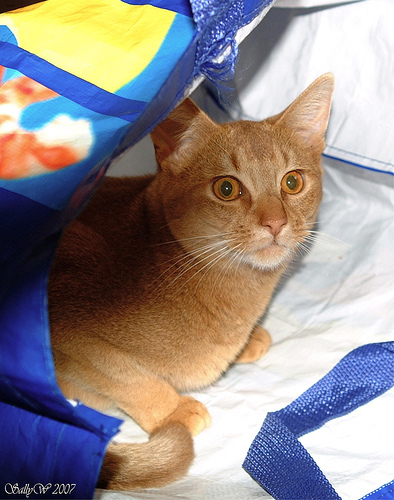

In [11]:
# 先預載一張測試影像（用 dataset 第一張）
# 這裡 download=True 第一次跑會花一點時間下載資料集
DATA_ROOT = './data'
_preview_ds = OxfordIIITPet(root=DATA_ROOT, split='trainval', download=True)
sample_img, sample_label = _preview_ds[0]
print(f'樣本標籤 / Label: {_preview_ds.classes[sample_label]}')
print(f'原圖尺寸 / Image size: {sample_img.size}')
sample_img

In [12]:
# 用 processor 把 PIL → tensor（含 resize、normalize）
inputs = processor(images=sample_img, return_tensors='pt').to(DEVICE)
print(f'pixel_values shape: {tuple(inputs["pixel_values"].shape)}  (B, C, H, W)')
print(f'  ↑ processor 把 PIL → 224×224 → normalize → 包成 batch')

with torch.no_grad():
    outputs = model(**inputs)

hidden = outputs.last_hidden_state
print(f'\nlast_hidden_state shape: {tuple(hidden.shape)}  (B, num_tokens, dim)')

# 拆解 token 序列
B, N, D = hidden.shape
n_reg = model.config.num_register_tokens
n_patches = N - 1 - n_reg
grid = int(n_patches ** 0.5)
patch_start = 1 + n_reg     # patches 在 sequence 裡的起點 index（之後的 cell 會用到）

print(f'\n── Token 拆解 / Token Breakdown ──')
print(f'  Token 0       : [CLS]              shape={tuple(hidden[:, 0].shape)}')
print(f'  Token 1..{n_reg}     : Registers (×{n_reg})     shape={tuple(hidden[:, 1:1+n_reg].shape)}')
print(f'  Token {1+n_reg}..{N-1}  : Patches (×{n_patches} = {grid}×{grid} grid)  shape={tuple(hidden[:, 1+n_reg:].shape)}')
print(f'  Embedding dim : {D}')
print(f'  patch_start   : {patch_start}  ← 後面 cells 用這個 index 跳過 CLS+registers')

pixel_values shape: (1, 3, 224, 224)  (B, C, H, W)
  ↑ processor 把 PIL → 224×224 → normalize → 包成 batch

last_hidden_state shape: (1, 261, 384)  (B, num_tokens, dim)

── Token 拆解 / Token Breakdown ──
  Token 0       : [CLS]              shape=(1, 384)
  Token 1..4     : Registers (×4)     shape=(1, 4, 384)
  Token 5..260  : Patches (×256 = 16×16 grid)  shape=(1, 256, 384)
  Embedding dim : 384
  patch_start   : 5  ← 後面 cells 用這個 index 跳過 CLS+registers


In [13]:
outputs

BaseModelOutputWithPooling(last_hidden_state=tensor([[[ 0.3499, -0.0930,  0.0831,  ...,  0.8929, -0.4927, -3.2301],
         [ 0.3895,  0.2982, -1.2863,  ...,  1.0579, -1.6757, -2.6217],
         [ 0.5161, -0.7707, -0.8237,  ...,  0.0951,  0.1778, -0.3364],
         ...,
         [ 1.2687, -0.3144, -0.8556,  ..., -0.2169, -0.6541, -1.7173],
         [ 1.3611,  0.1015, -0.5795,  ..., -0.3002, -0.9127, -1.7795],
         [ 0.5838, -0.5470,  0.0115,  ..., -0.3774, -0.2405, -0.7552]]],
       device='mps:0'), pooler_output=tensor([[ 0.3499, -0.0930,  0.0831, -0.1302,  0.2980, -0.5850,  1.4605,  0.2568,
         -0.9749,  0.7328,  2.0938, -0.4155,  0.1387, -0.9347, -0.7730,  0.5199,
         -0.2120,  0.5999, -0.3006,  0.6212,  1.3957,  0.9445, -2.9529,  2.9645,
         -0.3757, -0.0741,  1.1144, -0.1062, -0.3413, -0.6444, -0.4642, -3.3776,
         -0.4260, -3.2446, -1.1717, -0.0475, -0.2461, -0.5946,  2.6630, -1.0133,
         -1.2412, -0.0851,  0.9476,  0.4875,  0.2434, -1.3645,  1.6181

### 怎麼解讀 `outputs.last_hidden_state`？

**`outputs.last_hidden_state` 就是「261 個 token，每個 token 是 384 維向量」**——shape `(B=1, 261, 384)`。可以想成一張 261 × 384 的試算表：

```
                  +----- 384 維（每個 token 的「特徵向量」）-----+
                  dim 0   dim 1   dim 2   ...           dim 383
Token 0 [CLS]   [  0.12,  -0.55,   0.81, ...,            0.03 ]   <- 全圖摘要
Token 1 [R1]    [ -0.41,   0.22,   0.15, ...,           -0.18 ]   <- register
Token 2 [R2]    [  ...                                        ]   <- register
Token 3 [R3]    [  ...                                        ]   <- register
Token 4 [R4]    [  ...                                        ]   <- register
Token 5 [p1]    [  0.33,  -0.07,   0.49, ...,            0.21 ]   <- 原圖 (0,0) 那塊 14x14 pixel
Token 6 [p2]    [  ...                                        ]   <- 原圖 (0,1) 那塊
   ...
Token 260[p256] [  ...                                        ]   <- 原圖 (15,15) 那塊
```

**每一格那 0.12 之類的數字**，是 ViT 經過 12 層 attention + MLP 學出來的 latent feature——**不能**直接看哪個 dim 是「眼睛」、哪個 dim 是「毛皮」（不像 CNN 前幾層有可解釋的 channel）。要靠下游用法才能把它變成有用的資訊。

### 名字的意思

- **last** = 最後一層 transformer block 的輸出（**不是**「最終預測」的意思）
- **hidden_state** = 「中間層表徵」，是模型內部的 latent 向量，**不是 logits**
- 所以全名 = 「最後一層的中間表徵」

對比：

| 屬性 | 是什麼 | shape |
|---|---|---|
| `outputs.last_hidden_state` | 最後一層的輸出 | `(B, 261, 384)` |
| `outputs.hidden_states` (要 `output_hidden_states=True`) | **每一層**的輸出 | tuple of 13 個 `(B, 261, 384)` |
| `outputs.attentions` (要 `output_attentions=True`) | 每層的 attention matrix | tuple of 12 個 `(B, 6, 261, 261)` |
| `outputs.pooler_output` | DINOv2 沒有這個（有些 BERT-style 模型才有） | — |

> ⚠️ **沒有 logits**：DINOv2 是 **backbone**，不是 classifier——它只輸出 features，分類要你自己接 head。這跟 `AutoModelForImageClassification` 不一樣（那個會多一層 classification head 給 logits）。

### 怎麼用？看你要做什麼任務

```python
# --- 圖像分類 / image retrieval：只取 CLS ---
image_feature = outputs.last_hidden_state[:, 0]      # (B, 384)
# 這就是「整張圖的 384 維代表向量」，餵給 kNN / linear classifier

# --- 語意分割 / dense prediction：取 patches ---
patch_features = outputs.last_hidden_state[:, 5:]    # (B, 256, 384)
spatial = patch_features.reshape(B, 16, 16, 384)     # 還原成 grid
# 每個 (i,j) 位置一個 384 維向量，可以接 segmentation head

# --- 不要用 register tokens 做下游任務 ---
# outputs.last_hidden_state[:, 1:5]  <- 這 4 個是「模型內部暫存」，
# 對應不到原圖任何位置，拿來分類效果差
```

### 直觀比喻

把 `last_hidden_state` 想成模型「**讀完整張圖之後寫的 261 行筆記**」：
- 第 0 行（CLS）：「整張圖的總結」
- 第 1–4 行（registers）：「工作便條，幫我記些全域 statistics」
- 第 5–260 行（patches）：「對應原圖 16×16 個區塊，每塊我都看了，這是我對它的理解」

下游任務就是「決定要讀哪幾行筆記、怎麼用」——第 7 章開始我們就會做這件事（kNN 用 CLS、第 11 章 attention map 用 patches）。


### 順著 forward pass 看 tensor shape

理解神經網路最有效的方式之一是**逐步追蹤 tensor shape**：哪一步 batch 維被攤平？哪一步 channel 從 384 變 1536 又變回 384？這節我們做兩件事：

1. **巨觀**：用 `output_hidden_states=True` 看 12 層 transformer block 的輸出 shape——會發現 ViT 全程**形狀不變**（這跟 CNN 漸縮 H/W 的設計哲學完全相反）
2. **微觀**：把**單一個 transformer block** 拆開、逐 line 呼叫，看內部的 Q/K/V projection、attention matrix、MLP 展開/壓縮——這就是 ViT 的「心臟」

看完這兩個 cell 你就會建立起 ViT 的「shape mental model」：

```
Image (1,3,224,224)
    │
    │  patch embed (Conv2d k=14)
    ▼
(1, 256, 384)  ← 256 個 14×14 patch，每個變 384 維
    │  + CLS + 4 registers + pos embed
    ▼
(1, 261, 384) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
    │  block 1   (內部：384→Q/K/V→attention→384→1536→384)│
    ▼                                                    │
(1, 261, 384)                                            │  ← shape 一路
    │  block 2  (同樣的 attention + MLP，不同權重)       │     完全不變
    ▼                                                    │
 ... 12 層 ...                                           │
    │                                                    │
    ▼                                                    │
(1, 261, 384) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛
    │  final LayerNorm
    ▼
outputs.last_hidden_state = (1, 261, 384)
    │  └── outputs.pooler_output = hidden[:, 0] = (1, 384)  ← 就是 CLS
```


In [14]:
# ─── 巨觀：12 層 transformer block 的輸出 shape ───
with torch.no_grad():
    out_hs = model(**inputs, output_hidden_states=True)

# hidden_states 是 tuple of 13 個 tensor:
#   [0]    = embeddings 輸出（= block 0 的 input）
#   [1..12] = 12 個 block 各自的輸出
print(f'len(hidden_states) = {len(out_hs.hidden_states)}  (= 1 embeddings + 12 blocks)\n')

print(f'{"層":18s} {"shape":22s} {"mean":>9s} {"std":>8s} {"|max|":>8s}')
print('─' * 67)
for i, h in enumerate(out_hs.hidden_states):
    label = '[embeddings out]' if i == 0 else f'block {i:2d} out'
    print(f'{label:18s} {str(tuple(h.shape)):22s} '
          f'{h.mean().item():9.4f} {h.std().item():8.4f} {h.abs().max().item():8.3f}')

# 最後還會經過一層 final LayerNorm
final = model.layernorm(out_hs.hidden_states[-1])
print(f'{"final LayerNorm":18s} {str(tuple(final.shape)):22s} '
      f'{final.mean().item():9.4f} {final.std().item():8.4f} {final.abs().max().item():8.3f}')
print(f'\n   ↑ 這個 = outputs.last_hidden_state，差異: '
      f'{(final - outputs.last_hidden_state).abs().max().item():.2e}')

print(f'\n★ 觀察：shape 完全沒變 (1, 261, 384)——ViT 是「同形狀的反覆精煉」，')
print(f'  和 CNN「H/W 漸縮、C 漸增」是完全不同的設計哲學。')
print(f'  但 mean/std 會慢慢漂移——資訊在「被重新組織」、不是「被壓縮」。')

len(hidden_states) = 13  (= 1 embeddings + 12 blocks)

層                  shape                       mean      std    |max|
───────────────────────────────────────────────────────────────────
[embeddings out]   (1, 261, 384)             0.0045   0.2559    2.919
block  1 out       (1, 261, 384)            -0.0063   0.1386    2.576
block  2 out       (1, 261, 384)            -0.0108   0.1001    2.713
block  3 out       (1, 261, 384)            -0.0095   0.0883    2.595
block  4 out       (1, 261, 384)            -0.0094   0.0918    2.677
block  5 out       (1, 261, 384)            -0.0117   0.3710  103.279
block  6 out       (1, 261, 384)            -0.0092   0.3744  103.038
block  7 out       (1, 261, 384)            -0.0118   0.3848  103.045
block  8 out       (1, 261, 384)            -0.0149   0.4254  102.767
block  9 out       (1, 261, 384)            -0.0116   0.5295  102.546
block 10 out       (1, 261, 384)            -0.0227   0.7677  102.362
block 11 out       (1, 261, 384)     

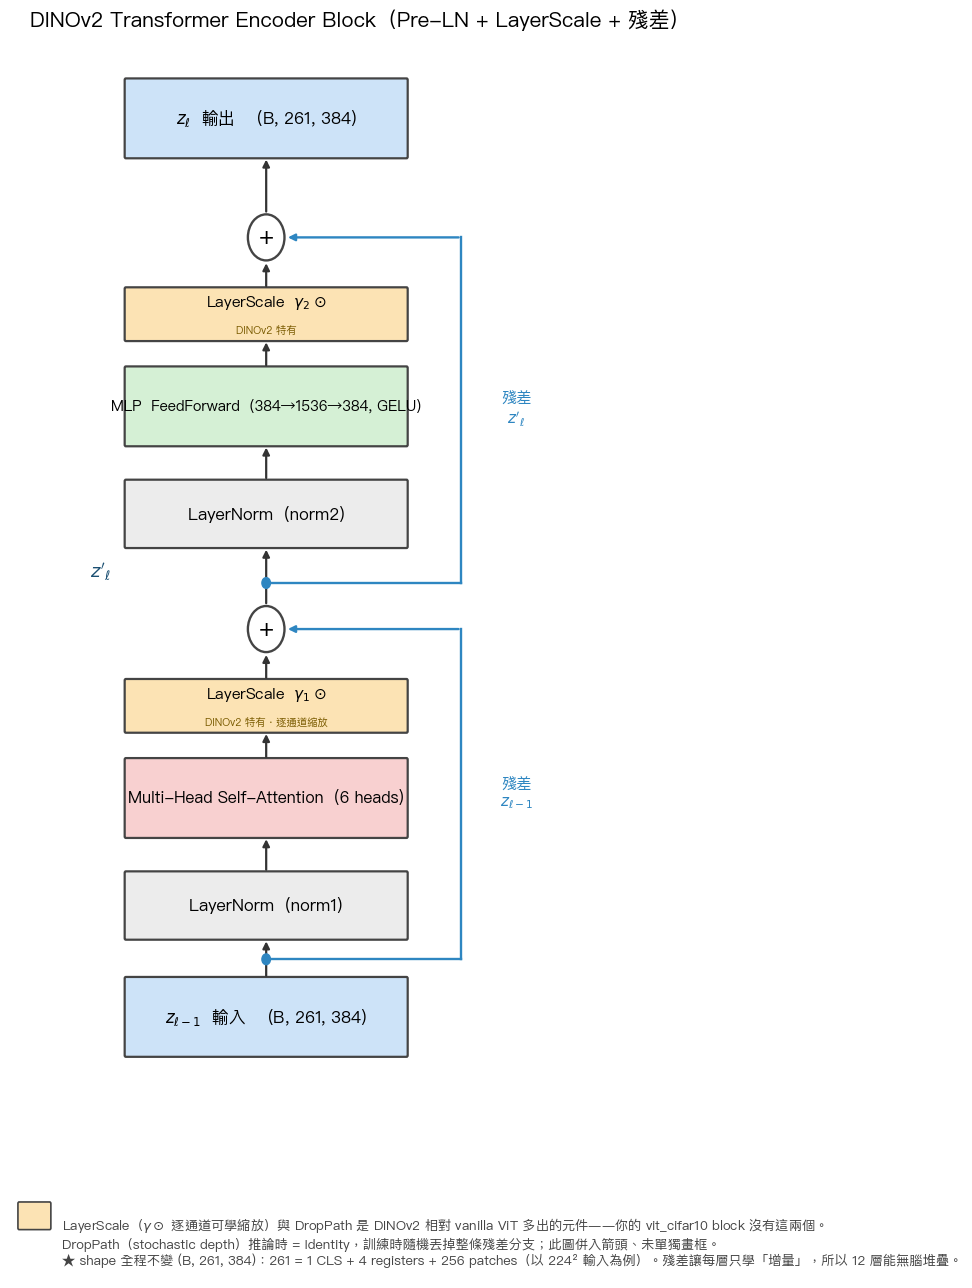

In [15]:
# 視覺化：DINOv2 Transformer Encoder Block 的結構圖
# 這是上一個 cell（手拆 block 0）的「資料流方塊圖」版本——把 norm / attention / MLP / 殘差畫成圖。
# ⚠️ 與 vanilla ViT（你的 vit_cifar10）最大差異：DINOv2 多了 LayerScale（γ⊙）與 DropPath。
#    所有數字都從 model.config 讀，換模型會自動更新。
D    = model.config.hidden_size                          # 384
Hh   = model.config.num_attention_heads                  # 6
mlph = int(D * getattr(model.config, 'mlp_ratio', 4))    # 1536
nreg = model.config.num_register_tokens                  # 4
psz  = model.config.patch_size                           # 14
npat = (224 // psz) ** 2                                  # 256（以 224² 輸入為例）
Ntok = 1 + nreg + npat                                   # 261
shp  = f'(B, {Ntok}, {D})'

cx = 4.2
fig, ax = plt.subplots(figsize=(9.5, 13.0))
ax.axis('off')
ax.set_title('DINOv2 Transformer Encoder Block（Pre-LN + LayerScale + 殘差）',
             fontsize=15, pad=16, fontweight='bold')

C = dict(io='#CDE3F8', norm='#ECECEC', attn='#F8D0D0', mlp='#D5F0D5', ls='#FCE3B4')

def box(cy, h, text, fc, fs=12, w=4.6, sub=None):
    ax.add_patch(mpatches.FancyBboxPatch((cx-w/2, cy-h/2), w, h, boxstyle='round,pad=0.02',
                                         facecolor=fc, edgecolor='#444', linewidth=1.6))
    if sub:
        ax.text(cx, cy+0.15, text, ha='center', va='center', fontsize=fs)
        ax.text(cx, cy-0.21, sub, ha='center', va='center', fontsize=fs-3.5,
                color='#7a5b00', style='italic')
    else:
        ax.text(cx, cy, text, ha='center', va='center', fontsize=fs)

def arrow(y0, y1):
    ax.annotate('', xy=(cx, y1), xytext=(cx, y0),
                arrowprops=dict(arrowstyle='-|>', lw=1.6, color='#333'))

def circ(cy, r=0.30):
    ax.add_patch(mpatches.Circle((cx, cy), r, facecolor='white', edgecolor='#444', lw=1.7))
    ax.text(cx, cy, '+', ha='center', va='center', fontsize=18, fontweight='bold')

y_in, y_n1, y_at, y_l1, y_a1, y_n2, y_mlp, y_l2, y_a2, y_out = \
    0.8, 2.25, 3.65, 4.85, 5.85, 7.35, 8.75, 9.95, 10.95, 12.5

box(y_in,  1.0,  f'$z_{{\\ell-1}}$  輸入    {shp}', C['io'])
arrow(y_in+0.5, y_n1-0.43)
box(y_n1,  0.85, 'LayerNorm  (norm1)', C['norm'])
arrow(y_n1+0.43, y_at-0.5)
box(y_at,  1.0,  f'Multi-Head Self-Attention  ({Hh} heads)', C['attn'], fs=11.5)
arrow(y_at+0.5, y_l1-0.33)
box(y_l1,  0.66, 'LayerScale  $\\gamma_1 \\odot$', C['ls'], fs=11, sub='DINOv2 特有・逐通道縮放')
arrow(y_l1+0.33, y_a1-0.30)
circ(y_a1)
arrow(y_a1+0.30, y_n2-0.43)
box(y_n2,  0.85, 'LayerNorm  (norm2)', C['norm'])
arrow(y_n2+0.43, y_mlp-0.5)
box(y_mlp, 1.0,  f'MLP  FeedForward  ({D}→{mlph}→{D}, GELU)', C['mlp'], fs=10.5)
arrow(y_mlp+0.5, y_l2-0.33)
box(y_l2,  0.66, 'LayerScale  $\\gamma_2 \\odot$', C['ls'], fs=11, sub='DINOv2 特有')
arrow(y_l2+0.33, y_a2-0.30)
circ(y_a2)
arrow(y_a2+0.30, y_out-0.5)
box(y_out, 1.0,  f'$z_\\ell$  輸出    {shp}', C['io'])

ax.text(cx-2.55, (y_a1+y_n2)/2, "$z'_\\ell$", ha='right', va='center', fontsize=13, color='#1B4F72')

BLUE = '#2E86C1'
x_rail = 7.4
def residual(y_branch, y_add, label):
    ax.add_patch(mpatches.Circle((cx, y_branch), 0.07, color=BLUE, zorder=5))   # 分流點
    ax.plot([cx, x_rail], [y_branch, y_branch], color=BLUE, lw=1.7)             # 往右
    ax.plot([x_rail, x_rail], [y_branch, y_add], color=BLUE, lw=1.7)            # 往上
    ax.annotate('', xy=(cx+0.31, y_add), xytext=(x_rail, y_add),                # 回到 + 號
                arrowprops=dict(arrowstyle='-|>', lw=1.7, color=BLUE))
    ax.text(x_rail+0.9, (y_branch+y_add)/2, label, ha='center', va='center',
            fontsize=11, color=BLUE)

residual(1.55, y_a1, '殘差\n$z_{\\ell-1}$')
residual(6.45, y_a2, "殘差\n$z'_\\ell$")

ax.add_patch(mpatches.FancyBboxPatch((0.15, -1.95), 0.5, 0.32, boxstyle='round,pad=0.02',
                                     facecolor=C['ls'], edgecolor='#444', linewidth=1.2))
ax.text(0.85, -1.79,
        'LayerScale（$\\gamma\\odot$ 逐通道可學縮放）與 DropPath 是 DINOv2 相對 vanilla ViT 多出的元件——'
        '你的 vit_cifar10 block 沒有這兩個。\n'
        'DropPath（stochastic depth）推論時 = Identity，訓練時隨機丟掉整條殘差分支；此圖併入箭頭、未單獨畫框。\n'
        f'★ shape 全程不變 {shp}：{Ntok} = 1 CLS + {nreg} registers + {npat} patches（以 224² 輸入為例）。'
        '殘差讓每層只學「增量」，所以 12 層能無腦堆疊。',
        ha='left', va='top', fontsize=9.5, color='#444')

ax.set_xlim(0, 11.5); ax.set_ylim(-2.6, 13.4)
plt.tight_layout(); plt.show()


In [16]:
# ─── 微觀：把單一個 transformer block 拆開，逐步看 shape ───
# 12 個 block 都做同樣的事，只是權重不同；這裡用 block 0 示範
#
# ⚠️ 版本敏感：下面用到的內部屬性名（norm1 / attention.attention / layer_scale1 /
#    mlp.fc1 / attn_inner.scaling …）是 HF transformers 的實作細節，會隨版本改名。
#    本 cell 已在 transformers 4.57.x 驗證可跑。若你升級後報 AttributeError，
#    用 `print(block0)` 或 `dir(block0)` 重新對照屬性名即可。
block0 = model.encoder.layer[0]
h_in   = out_hs.hidden_states[0]      # block 0 的 input = embeddings 的 output

attn_inner = block0.attention.attention      # 內層 Q/K/V SelfAttention
H_heads    = attn_inner.num_attention_heads  # 6
d_head     = attn_inner.attention_head_size  # 384/6 = 64

print(f'═══ Block 0 內部運算（其他 11 個 block 流程完全相同）═══')
print(f'    heads={H_heads}, d_head={d_head}, hidden_size={H_heads*d_head}\n')
print(f'input             : {tuple(h_in.shape)}\n')

# ── Path 1: Self-Attention 路徑 ──
print(f'── ① Self-Attention path ──')
h1 = block0.norm1(h_in)
print(f'  norm1(h_in)     : {tuple(h1.shape)}   (LayerNorm 不改 shape)')

B_, N_, Dim_ = h1.shape
q = attn_inner.query(h1).view(B_, N_, H_heads, d_head).transpose(1, 2)
k = attn_inner.key  (h1).view(B_, N_, H_heads, d_head).transpose(1, 2)
v = attn_inner.value(h1).view(B_, N_, H_heads, d_head).transpose(1, 2)
print(f'  Q = h1 @ W_Q    : {tuple(q.shape)}  (B, heads, N, d_head)')
print(f'  K = h1 @ W_K    : {tuple(k.shape)}')
print(f'  V = h1 @ W_V    : {tuple(v.shape)}')

scores = (q @ k.transpose(-2, -1)) * attn_inner.scaling
print(f'  Q @ Kᵀ / √d     : {tuple(scores.shape)}  (B, heads, N, N) ← attention matrix')

probs = scores.softmax(-1)
print(f'  softmax(.,-1)   : {tuple(probs.shape)}  (每 row 加總 = 1)')

ctx = probs @ v
print(f'  probs @ V       : {tuple(ctx.shape)}  (B, heads, N, d_head)')

ctx_concat = ctx.transpose(1, 2).reshape(B_, N_, Dim_)
print(f'  concat heads    : {tuple(ctx_concat.shape)}  (B, N, hidden_size) ← reshape 把 heads 攤回去')

attn_proj = block0.attention.output.dense(ctx_concat)
attn_proj = block0.layer_scale1(attn_proj)
h_mid = h_in + attn_proj                                # residual
print(f'  output proj     : {tuple(attn_proj.shape)}')
print(f'  + h_in (residual): {tuple(h_mid.shape)}\n')

# ── Path 2: MLP 路徑 ──
print(f'── ② MLP path ──')
h2 = block0.norm2(h_mid)
print(f'  norm2(h_mid)    : {tuple(h2.shape)}')

h2_up = block0.mlp.fc1(h2)
print(f'  fc1 (384→1536)  : {tuple(h2_up.shape)}  ← MLP 「展開」4× (mlp_ratio=4)')

h2_act = block0.mlp.activation(h2_up)
print(f'  GELU            : {tuple(h2_act.shape)}  (shape 不變，只加非線性)')

h2_down = block0.mlp.fc2(h2_act)
h2_down = block0.layer_scale2(h2_down)
print(f'  fc2 (1536→384)  : {tuple(h2_down.shape)}  ← MLP 「壓縮」回來')

h_out = h_mid + h2_down                                  # residual
print(f'  + h_mid (residual): {tuple(h_out.shape)}\n')

# ── 驗證：手動算的和 HuggingFace 跑出來的一樣 ──
hf_out = out_hs.hidden_states[1]
diff = (h_out - hf_out).abs().max().item()
print(f'★ 對照 HF 跑出來的 block 0 output: max abs diff = {diff:.2e}  (數值上等於 0 ✓)')

═══ Block 0 內部運算（其他 11 個 block 流程完全相同）═══
    heads=6, d_head=64, hidden_size=384

input             : (1, 261, 384)

── ① Self-Attention path ──
  norm1(h_in)     : (1, 261, 384)   (LayerNorm 不改 shape)
  Q = h1 @ W_Q    : (1, 6, 261, 64)  (B, heads, N, d_head)
  K = h1 @ W_K    : (1, 6, 261, 64)
  V = h1 @ W_V    : (1, 6, 261, 64)
  Q @ Kᵀ / √d     : (1, 6, 261, 261)  (B, heads, N, N) ← attention matrix
  softmax(.,-1)   : (1, 6, 261, 261)  (每 row 加總 = 1)
  probs @ V       : (1, 6, 261, 64)  (B, heads, N, d_head)
  concat heads    : (1, 261, 384)  (B, N, hidden_size) ← reshape 把 heads 攤回去
  output proj     : (1, 261, 384)
  + h_in (residual): (1, 261, 384)

── ② MLP path ──
  norm2(h_mid)    : (1, 261, 384)
  fc1 (384→1536)  : (1, 261, 1536)  ← MLP 「展開」4× (mlp_ratio=4)
  GELU            : (1, 261, 1536)  (shape 不變，只加非線性)
  fc2 (1536→384)  : (1, 261, 384)  ← MLP 「壓縮」回來
  + h_mid (residual): (1, 261, 384)

★ 對照 HF 跑出來的 block 0 output: max abs diff = 0.00e+00  (數值上等於 0 ✓)


**重點看出三件事：**

1. **整個 block 的 input/output shape 完全一樣** `(1, 261, 384)`——這就是為什麼 12 層可以無腦堆疊
2. **MLP 內部有個「pancake」**：384 → 1536 → 384。中間擴張 4× 是為了「先把訊號攤平到更大的空間做非線性處理、再壓縮回來」——這是 transformer 的標準設計，**1536 維中間層佔了模型參數量的大頭**
3. **Two residual paths**：每個 block 走兩條 skip connection（attention + MLP），這是 transformer 訓練得起來的關鍵（沒有 residual 12 層根本訓練不起來）

★ **參數量小算術**（DINOv2-S 一個 block）：
- Q/K/V projection: 3 × (384 × 384) ≈ 442k
- output projection: 384 × 384 ≈ 147k
- MLP fc1: 384 × 1536 ≈ 590k
- MLP fc2: 1536 × 384 ≈ 590k
- → 一個 block 約 **1.77M params**，12 層 ≈ 21M。和 model 報的 21M 對得起來 ✓

現在你可以理解 token sequence layout 那張圖了——下一個 cell 把它畫出來。

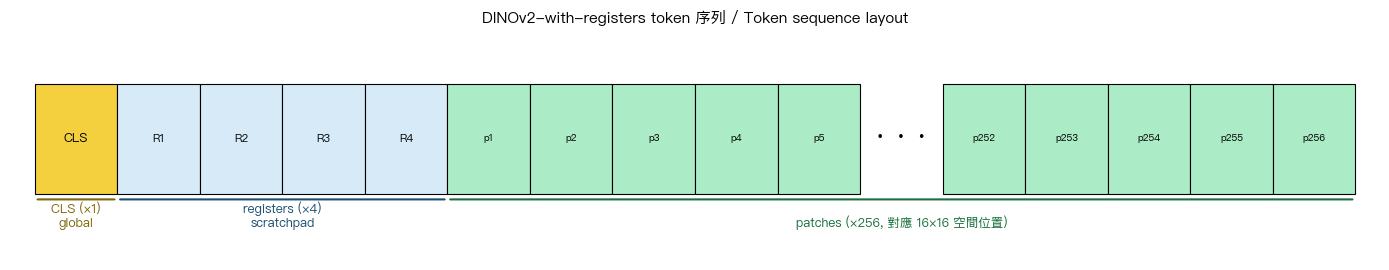


各 token 的用途：
• [CLS]      → 全圖摘要，常用做 image-level feature（分類）
• Registers  → 模型「計算暫存」，不對應空間位置，不該用於 dense task
• Patches    → 對應原圖 14×14 像素區塊，可重排成空間 grid 做 segmentation/attention map


In [17]:
# 視覺化：token 序列構成 / Visualize the token sequence layout
# 用「壓縮座標」畫圖：每個方塊間隔 1，中間 ... 代表省略的 patch
fig, ax = plt.subplots(figsize=(14, 2.8))

# 配置：CLS(1) + Registers(n_reg) + 前 5 patch + gap + 後 5 patch
xs_cls   = [0]
xs_reg   = list(range(1, 1 + n_reg))
xs_p1    = list(range(1 + n_reg, 1 + n_reg + 5))         # 前 5 個 patch
gap_x    = 1 + n_reg + 5 + 0.5                            # ... 的位置
xs_p2    = list(range(1 + n_reg + 6, 1 + n_reg + 6 + 5))  # 後 5 個 patch
xmax     = xs_p2[-1] + 1

ax.set_xlim(-0.3, xmax + 0.3); ax.set_ylim(-0.6, 1.4); ax.axis('off')

def draw_box(x, color, label, fontsize=8, bold=False):
    ax.add_patch(mpatches.Rectangle((x, 0), 1, 1, facecolor=color, edgecolor='black', linewidth=0.8))
    weight = 'bold' if bold else 'normal'
    ax.text(x + 0.5, 0.5, label, ha='center', va='center', fontsize=fontsize, fontweight=weight)

# CLS
draw_box(xs_cls[0], '#F4D03F', 'CLS', fontsize=9, bold=True)
# Registers
for i, x in enumerate(xs_reg):
    draw_box(x, '#D6EAF8', f'R{i+1}', fontsize=8)
# 前 5 patch
for i, x in enumerate(xs_p1):
    draw_box(x, '#ABEBC6', f'p{i+1}', fontsize=7)
# 省略符號
ax.text(gap_x, 0.5, '· · ·', ha='center', va='center', fontsize=18)
# 後 5 patch
for i, x in enumerate(xs_p2):
    draw_box(x, '#ABEBC6', f'p{n_patches - 4 + i}', fontsize=7)

# 底下分組 label（用換行符把兩行字串接起來）
ax.annotate('', xy=(0, -0.05), xytext=(1, -0.05),
            arrowprops=dict(arrowstyle='-', color='#7D6608', lw=1.5))
ax.text(0.5, -0.3, 'CLS (×1)\nglobal', ha='center', fontsize=9, color='#7D6608')

ax.annotate('', xy=(xs_reg[0], -0.05), xytext=(xs_reg[-1] + 1, -0.05),
            arrowprops=dict(arrowstyle='-', color='#1B4F72', lw=1.5))
ax.text((xs_reg[0] + xs_reg[-1] + 1) / 2, -0.3,
        f'registers (×{n_reg})\nscratchpad', ha='center', fontsize=9, color='#1B4F72')

ax.annotate('', xy=(xs_p1[0], -0.05), xytext=(xs_p2[-1] + 1, -0.05),
            arrowprops=dict(arrowstyle='-', color='#196F3D', lw=1.5))
ax.text((xs_p1[0] + xs_p2[-1] + 1) / 2, -0.3,
        f'patches (×{n_patches}, 對應 {grid}×{grid} 空間位置)',
        ha='center', fontsize=9, color='#196F3D')

ax.set_title('DINOv2-with-registers token 序列 / Token sequence layout', fontsize=11, pad=12)
plt.tight_layout(); plt.show()

print(f'\n各 token 的用途：')
print(f'• [CLS]      → 全圖摘要，常用做 image-level feature（分類）')
print(f'• Registers  → 模型「計算暫存」，不對應空間位置，不該用於 dense task')
print(f'• Patches    → 對應原圖 14×14 像素區塊，可重排成空間 grid 做 segmentation/attention map')


### 用 attention map 把 forward pass「看出來」

前面我們知道 forward pass 的輸出是 `(1, 261, 384)` 的 hidden states——但**模型在路上到底「看」了什麼**？最直接的方法是把 attention weights 拿出來畫。

在 forward pass 的每一層 Transformer Block 裡都會算：
$$ A_{ij} = \mathrm{softmax}\!\left(\frac{Q_i K_j^\top}{\sqrt{d}}\right) $$

`A[i, j]` 就是「token $i$ 在更新自己時，從 token $j$ 取了多少資訊」。

我們特別關心**最後一層的 `[CLS] → patches`**——也就是 `A[0, 5:]`——因為這正是 CLS 最終 embedding「從哪些圖像區域聚合資訊」的證據。如果模型表現好，這張 heatmap 應該會**亮在物體（寵物）上**，而不是背景。

> 一個技術小坑：DINOv2 預設用 `sdpa` (PyTorch 加速版 attention)，但它**不會把 attention weights 算出來**（純張量運算融合掉了）。要拿到 attention 需要切回 `eager` 實作。


── out_attn.attentions 的結構 ──
  type           : tuple of 12 tensors (= 12 個 layer)
  每層 shape     : (1, 6, 261, 261)  (B, heads, N, N)
    ↑ N=261=1+4+256；heads=6；每層都有完整的 N×N attention matrix

── 一步步切出 CLS→patches attention ──
  last_attn (拿掉 B)    : (6, 261, 261)    (heads, N, N)
  cls_row = [:, 0, :]    : (6, 261)    (heads, N) ← CLS 看每個 token 多少
  cls_to_patches         : (6, 256)    (heads, n_patches=256)
  reshape 成 2D grid     : (6, 16, 16)    (heads, grid_h=16, grid_w=16)
  avg_attn (over heads)  : (16, 16)    (16, 16)

img_np (反 normalize 後): (224, 224, 3)   (H, W, 3)，pixel range [0, 1]



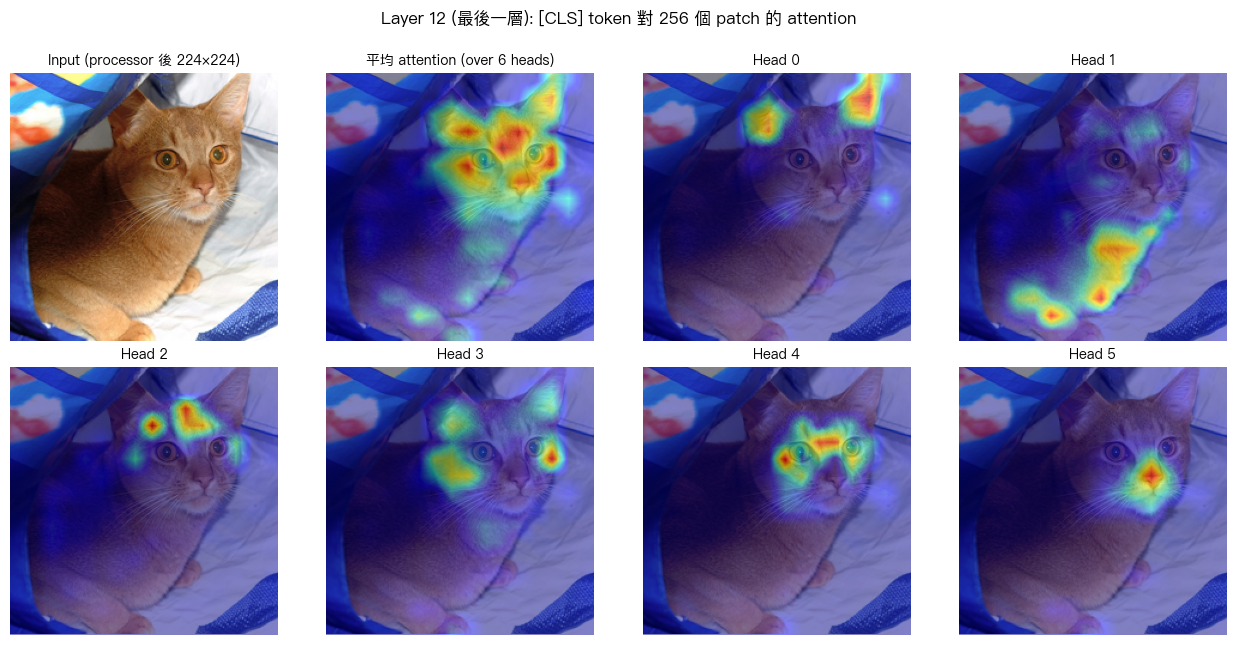

In [18]:
# ── Step 1: 切換成 eager attention，才能拿到 attention weights ──
# (DINOv2 預設用 sdpa，效能較好但不會顯式算出 attention matrix)
# 注意：之後 cells 也會繼續用 eager，稍慢但結果完全一樣
model.set_attn_implementation('eager')

# ── Step 2: 重跑 forward，這次要求輸出 attention ──
with torch.no_grad():
    out_attn = model(**inputs, output_attentions=True)

print('── out_attn.attentions 的結構 ──')
print(f'  type           : tuple of {len(out_attn.attentions)} tensors (= 12 個 layer)')
print(f'  每層 shape     : {tuple(out_attn.attentions[-1].shape)}  (B, heads, N, N)')
print(f'    ↑ N=261=1+4+256；heads=6；每層都有完整的 N×N attention matrix\n')

# ── Step 3: 拿最後一層 CLS → patches 的 attention ──
last_attn = out_attn.attentions[-1][0]            # 拿掉 batch dim
print(f'── 一步步切出 CLS→patches attention ──')
print(f'  last_attn (拿掉 B)    : {tuple(last_attn.shape)}    (heads, N, N)')

n_heads = last_attn.shape[0]
cls_row = last_attn[:, 0, :]                       # CLS (row 0) 對所有 token 的權重
print(f'  cls_row = [:, 0, :]    : {tuple(cls_row.shape)}    (heads, N) ← CLS 看每個 token 多少')

cls_to_patches = cls_row[:, patch_start:]          # 只留 patches，跳過 CLS+registers
print(f'  cls_to_patches         : {tuple(cls_to_patches.shape)}    (heads, n_patches=256)')

attn_grids = cls_to_patches.reshape(n_heads, grid, grid).cpu().numpy()
print(f'  reshape 成 2D grid     : {attn_grids.shape}    (heads, grid_h=16, grid_w=16)')

avg_attn = attn_grids.mean(0)
print(f'  avg_attn (over heads)  : {avg_attn.shape}    (16, 16)\n')

# ── Step 4: 還原 processor 處理後的 224×224 圖（反 normalize 才能用肉眼看）──
import numpy as np
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
img_np = inputs['pixel_values'][0].cpu().permute(1, 2, 0).numpy() * std + mean
img_np = np.clip(img_np, 0, 1)
H = W = img_np.shape[0]
print(f'img_np (反 normalize 後): {img_np.shape}   (H, W, 3)，pixel range [0, 1]\n')

# ── Step 5: 畫圖：原圖 + 平均 attention + 每個 head 各畫一張 ──
ncols = 4
nrows = (2 + n_heads + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows))
axes = axes.flatten()

def overlay(ax, heat, title):
    ax.imshow(img_np)
    heat_norm = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
    ax.imshow(heat_norm, cmap='jet', alpha=0.5,
              extent=(0, W, H, 0), interpolation='bilinear')
    ax.set_title(title, fontsize=10); ax.axis('off')

axes[0].imshow(img_np); axes[0].set_title('Input (processor 後 224×224)', fontsize=10); axes[0].axis('off')
overlay(axes[1], avg_attn, f'平均 attention (over {n_heads} heads)')
for h in range(n_heads):
    overlay(axes[2 + h], attn_grids[h], f'Head {h}')
for k in range(2 + n_heads, len(axes)):
    axes[k].axis('off')

plt.suptitle('Layer 12 (最後一層): [CLS] token 對 256 個 patch 的 attention', fontsize=12, y=1.00)
plt.tight_layout(); plt.show()

### 解讀這張圖

**這就是 forward pass 的「目擊證據」：**

1. **回顧整條路徑**：影像進來 → patch embedding 切成 256 個 token → 串上 CLS + 4 registers → 12 層 Transformer 反覆做 attention → 最後一層的 CLS 已經把整張圖的資訊「吸」進自己這 384 維。
2. **熱區的意義**：紅 / 黃色越亮，代表 CLS 在更新自己時越仰賴那塊 patch。亮在寵物身上 → 模型有抓到「主體」；亮在背景 → 表示這個 head 學到的不是主體偵測。
3. **每個 head 不同**：6 個 head 各自關注不同的視覺特徵（眼鼻、輪廓、毛皮紋理）。這就是 multi-head attention 「分工」的證據——不是冗餘，而是並行偵測多種 pattern。
4. **register tokens 的角色**：注意我們**跳過了 register 區域**（`patch_start = 1 + n_reg`）。如果把 CLS → registers 那段一起畫，會看到 register 也吃掉一部分 attention budget——那是模型「拿來放雜訊 / 全域 statistics 的暫存區」，不對應任何空間位置。

**和 forward pass 公式的對應：**

```
Block 1:  hidden = hidden + Attention(hidden) ...  ← 每層 attention 都會更新所有 token
Block 2:  hidden = hidden + Attention(hidden) ...
  ...                                              ← attention pattern 在前幾層比較鬆散
Block 12: hidden = hidden + Attention(hidden) ...  ← ★ 我們畫的就是這層的 A[CLS, patches]
         hidden[:, 0]  ←  這個 [CLS] 向量就是「上面那張 heatmap 加權平均出來的結果」
```

第 11 章我們會用更大的圖、再做有 / 無 registers 的對比；現在先建立**「CLS = 整圖摘要」**的直覺。

### 也來看 feature map：每個位置的 384 維向量「長什麼樣」

Attention map 告訴你「CLS 注意哪裡」；**feature map** 則是另一個角度——每個 patch 位置最終都得到一個 **384 維向量**（就是 `hidden[:, patch_start:]` 那段），把它們排回 `16×16` 空間 grid，就成了 ViT 版的 *feature map*。

和 CNN 的 feature map 有什麼差別？

| | CNN (e.g. ResNet) | ViT (DINOv2) |
|---|---|---|
| 形狀 | `(C, H, W)`，每層 H/W 漸縮 | `(N_patches, D)`，全程不變 |
| 「位置」概念 | 卷積天生對應空間，每個 pixel 有 receptive field | 需要 reshape 回 `(grid, grid, D)` 才看得出空間 |
| 通道意義 | 早層邊緣、深層語意 | 每個 dim 是 attention 學出來的 latent，**沒有固定意義** |

所以 ViT feature map 沒辦法像 CNN「印第 N 層第 K 個 channel」就一目了然——需要降維（PCA）才能看出語意。下面我們做三件事：

1. **Feature norm heatmap**：每個位置 384 維向量的 L2 norm，亮 = 該位置的特徵「能量強」
2. **PCA → RGB**：對 256 個 patch features 做 PCA 取前 3 components，當成 RGB 顯示——這是 DINO/DINOv2 paper 的經典視覺化，**同物體部位會被染成同顏色**
3. **單一 channel heatmap**：挑幾個維度直接畫，看看它們「亂不亂」


── 一步步把 patch features 變成 16×16 feature map ──
  hidden                 : (1, 261, 384)    (B, N=261, D=384)
  hidden[0, patch_start:]: (256, 384)    (256, 384) ← 拿掉 B、跳過 CLS+reg
  reshape 回空間 grid    : (16, 16, 384)    (grid_h, grid_w, dim) ← 這就是 feature map

(a) feat_norm = ||h_i||₂  : (16, 16)    (16, 16) ← 每位置一個純量
(b) pca.fit_transform     : (256, 3)    (256, 3) ← 256 個 patch 投影到 3 維
    reshape 成 RGB grid   : (16, 16, 3)    (16, 16, 3) ← 直接當圖片顯示
    explained variance    : [0.365 0.118 0.078]  (前 3 個方向解釋 56% 變異)
(c) feat_map[:, :, c]     : (16, 16)    (16, 16) ← 單一 channel 的空間分佈


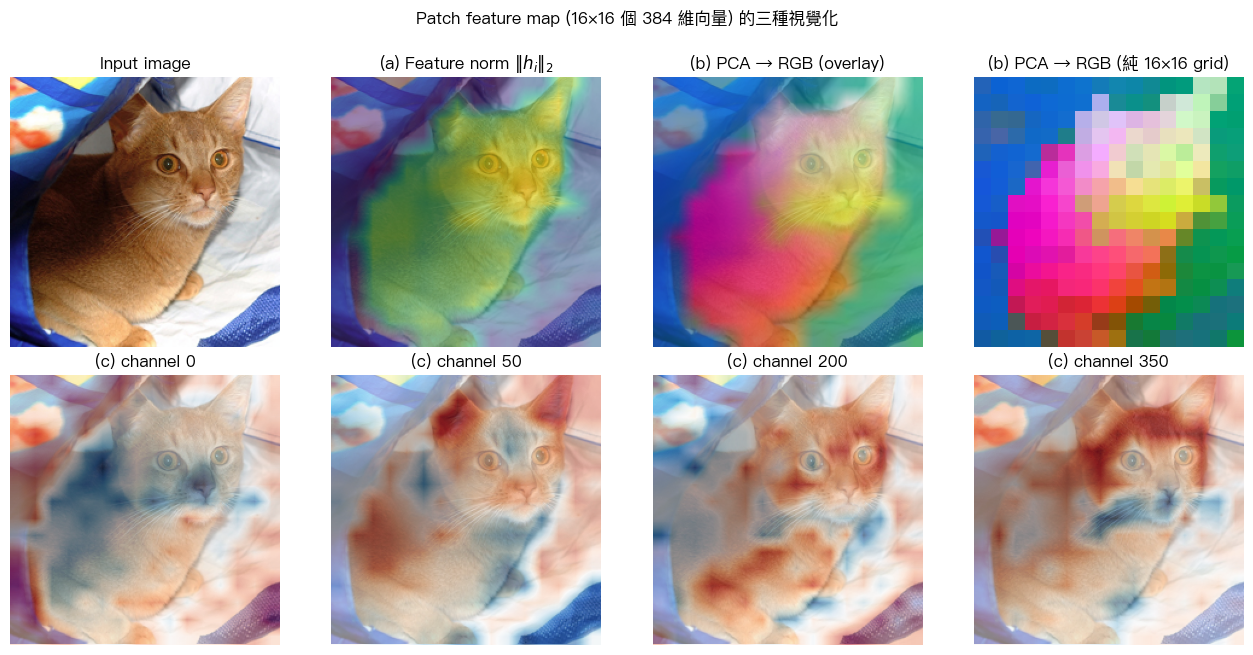

In [19]:
from sklearn.decomposition import PCA

# ── Step 1: 從上一步的 hidden 取出 patch features，reshape 回空間 grid ──
print('── 一步步把 patch features 變成 16×16 feature map ──')
print(f'  hidden                 : {tuple(hidden.shape)}    (B, N=261, D=384)')

patch_feats = hidden[0, patch_start:].cpu().numpy()
print(f'  hidden[0, patch_start:]: {patch_feats.shape}    (256, 384) ← 拿掉 B、跳過 CLS+reg')

feat_map = patch_feats.reshape(grid, grid, D)
print(f'  reshape 回空間 grid    : {feat_map.shape}    (grid_h, grid_w, dim) ← 這就是 feature map\n')

# ── Step 2: 三種視覺化 ──
# (a) L2 norm: 每個位置 384 維向量的長度
feat_norm = np.linalg.norm(feat_map, axis=-1)
print(f'(a) feat_norm = ||h_i||₂  : {feat_norm.shape}    (16, 16) ← 每位置一個純量')

# (b) PCA → RGB: 把 384 維壓到 3 維，當 R/G/B 通道
pca = PCA(n_components=3)
pca_feats = pca.fit_transform(patch_feats)
print(f'(b) pca.fit_transform     : {pca_feats.shape}    (256, 3) ← 256 個 patch 投影到 3 維')

pca_feats = (pca_feats - pca_feats.min(0)) / (pca_feats.max(0) - pca_feats.min(0) + 1e-8)
pca_rgb = pca_feats.reshape(grid, grid, 3)
print(f'    reshape 成 RGB grid   : {pca_rgb.shape}    (16, 16, 3) ← 直接當圖片顯示')
print(f'    explained variance    : {pca.explained_variance_ratio_.round(3)}  '
      f'(前 3 個方向解釋 {pca.explained_variance_ratio_.sum()*100:.0f}% 變異)')

# (c) 挑 4 個 channel 直接畫
picked_channels = [0, 50, 200, 350]
channel_maps = [feat_map[:, :, c] for c in picked_channels]
print(f'(c) feat_map[:, :, c]     : {channel_maps[0].shape}    (16, 16) ← 單一 channel 的空間分佈')

# ── Step 3: 排版 ──
fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
axes = axes.flatten()

axes[0].imshow(img_np); axes[0].set_title('Input image'); axes[0].axis('off')

axes[1].imshow(img_np)
fn_norm = (feat_norm - feat_norm.min()) / (feat_norm.max() - feat_norm.min() + 1e-8)
axes[1].imshow(fn_norm, cmap='viridis', alpha=0.55,
               extent=(0, W, H, 0), interpolation='bilinear')
axes[1].set_title(r'(a) Feature norm $\Vert h_i \Vert_2$'); axes[1].axis('off')

axes[2].imshow(img_np)
axes[2].imshow(pca_rgb, alpha=0.7,
               extent=(0, W, H, 0), interpolation='bilinear')
axes[2].set_title('(b) PCA → RGB (overlay)'); axes[2].axis('off')

axes[3].imshow(pca_rgb, interpolation='nearest')
axes[3].set_title('(b) PCA → RGB (純 16×16 grid)'); axes[3].axis('off')

for k, c in enumerate(picked_channels):
    ax = axes[4 + k]
    ax.imshow(img_np)
    ch = channel_maps[k]
    ch_norm = (ch - ch.min()) / (ch.max() - ch.min() + 1e-8)
    ax.imshow(ch_norm, cmap='RdBu_r', alpha=0.55,
              extent=(0, W, H, 0), interpolation='bilinear')
    ax.set_title(f'(c) channel {c}'); ax.axis('off')

plt.suptitle('Patch feature map (16×16 個 384 維向量) 的三種視覺化', fontsize=12, y=1.00)
plt.tight_layout(); plt.show()

### 解讀 feature map

**(a) Feature norm**——每個位置的特徵「強度」。在 DINOv2-with-registers 上，norm 通常分佈相對均勻；如果換成**沒有 registers 的版本**（第 12 章會做對比），背景常出現幾個 norm 異常大的「artifact」patch——那就是註冊 token 還沒被引入時，模型偷偷拿來放全域 statistics 的地方。

**(b) PCA → RGB**——這是 DINOv2 paper 最有名的視覺化。原本 256 個 patch 各是 384 維高維點，做 PCA 後我們只保留變異量最大的 3 個方向、當成 R/G/B：
- 如果模型學到「**語意相近的 patch → feature 相近**」，那同一個物體會被染成**同色塊**
- 物體 vs 背景會明顯分成不同顏色——這就是 segmentation 「免費」湧現出來的證據
- `explained_variance_ratio` 通常前 3 個就能解釋 50% 左右的變異，意思是「`384` 維雖然名義上很高維、但實際資料的有效維度低很多」

**(c) 單一 channel**——隨機挑幾個 dim 直接畫。會發現大部分 channel **看不出語意**（看起來像雜訊），這跟 CNN 不同。
- 原因：ViT 沒有 inductive bias 把「邊緣 / 紋理」綁定到特定 channel，每個 dim 的意義是 attention 過程中**emergent**的、且通常**分散在多個 dim 上**
- 真正有結構的訊號要靠**降維**（PCA / k-means / linear probe）才會浮現

### Feature map vs Attention map 的差別

| | Attention map | Feature map |
|---|---|---|
| 來源 | `outputs.attentions[-1]` (B, heads, N, N) | `outputs.last_hidden_state` (B, N, D) |
| 是什麼 | 「token i 從 token j 吸了多少資訊」的權重 | 每個 token 最終的 384 維向量 |
| 直覺 | **流動**——資訊從哪裡流到哪裡 | **結果**——流完之後每個位置存了什麼 |
| 用途 | 解釋性、定位（CLS 在看哪） | 下游任務（kNN、linear probe、segmentation） |

下游任務（第 7 章開始）用的就是 **feature map（或 CLS feature）**，不是 attention map。Attention map 純粹是「給人看」的解釋工具。


---
# Part III — 應用 / Application

> 把抽象的「好 features」變成 **可量化的下游效能**。先 kNN 給驚奇感，再 linear probe 給嚴謹感。

## 第 6 章：Oxford-IIIT Pet 資料準備

- 37 個類別（25 種狗 + 12 種貓品種）
- 約 7,349 張影像（train 3,680 / test 3,669）
- 細粒度分類：分辨「英短 vs 俄羅斯藍」、「貴賓 vs 比熊」這種等級

為何選這個資料集？粗類別任何 backbone 都會分對，**細粒度才看得出 features 是否真的有語意**。

In [20]:
# DINOv2 預訓練的 normalize 統計（ImageNet 標準）
DINO_MEAN = [0.485, 0.456, 0.406]
DINO_STD  = [0.229, 0.224, 0.225]

# 224x224：給 feature extraction（與預訓練設定一致）
# 這條 pipeline 精準復刻 AutoImageProcessor 的行為：
#   shortest-edge → 256 (BICUBIC) → center-crop 224 → ImageNet normalize
# ⚠️ processor 預設 resample=BICUBIC；torchvision 的 Resize 預設卻是 BILINEAR，
#    所以這裡「顯式指定 BICUBIC」才會和第 5 章 forward-pass 的前處理完全一致。
# 手寫而不直接用 processor，是為了讓 DataLoader 能逐張套用、批次抽 feature。
transform_224 = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=DINO_MEAN, std=DINO_STD),
])

train_ds = OxfordIIITPet(root=DATA_ROOT, split='trainval', download=True, transform=transform_224)
test_ds  = OxfordIIITPet(root=DATA_ROOT, split='test',     download=True, transform=transform_224)
NUM_CLASSES = len(train_ds.classes)

print(f'類別數 / Classes: {NUM_CLASSES}')
print(f'訓練樣本 / Train: {len(train_ds)}')
print(f'測試樣本 / Test : {len(test_ds)}')
print(f'前 5 類: {train_ds.classes[:5]} ...')

類別數 / Classes: 37
訓練樣本 / Train: 3680
測試樣本 / Test : 3669
前 5 類: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle'] ...


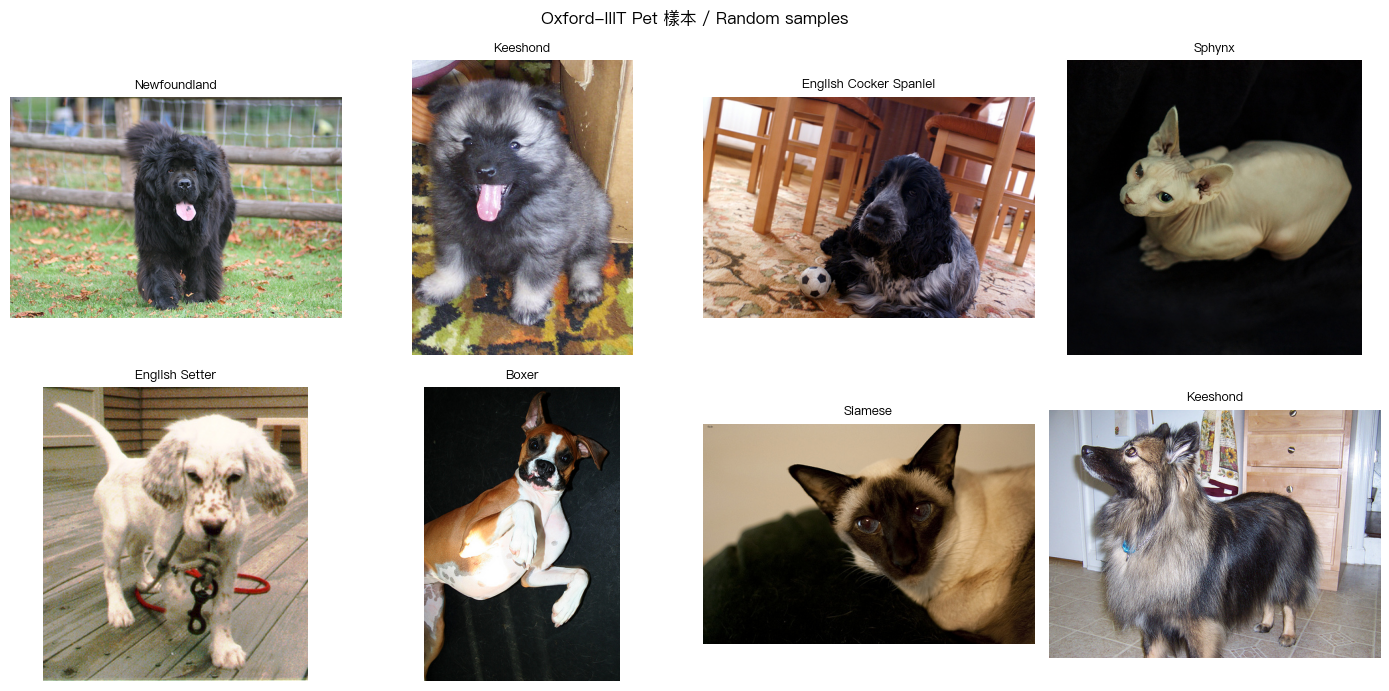

In [21]:
# 視覺化 8 張樣本 / Visualize 8 random samples
# 為了顯示原圖（不帶 normalize），另開一個 dataset
_vis_ds = OxfordIIITPet(root=DATA_ROOT, split='trainval', download=False)

idxs = np.random.RandomState(42).choice(len(_vis_ds), 8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, idx in zip(axes.flat, idxs):
    img, lbl = _vis_ds[idx]
    ax.imshow(img)
    ax.set_title(_vis_ds.classes[lbl], fontsize=9)
    ax.axis('off')
plt.suptitle('Oxford-IIIT Pet 樣本 / Random samples', fontsize=12)
plt.tight_layout(); plt.show()

## 第 7 章：Feature Extraction

把整個 train + test 跑過 DINOv2 一次，把每張圖變成一個 **384 維向量**。之後 kNN 和 linear probe 都用這些 cached features，**不用再過 backbone**——這就是 frozen-backbone evaluation 的標準做法。

### Pooling 策略決策

從 261 個 token 怎麼變成 1 個 image-level feature？有幾種選擇：

| 策略 | 公式 | 用途 |
|---|---|---|
| **CLS only** ⭐ | `hidden[:, 0]` | 標準做法，DINOv2 paper 用這個 |
| **Mean of patches** | `hidden[:, 5:].mean(dim=1)` | 對 dense feature 任務（detection、seg）較好 |
| **CLS + Mean patches** | `concat([cls, mean_patches])` | 兩者並用，dim 變 2× |

我們用 **CLS only**（簡單、與論文一致）。下方函式裡你可以隨時切換 `pool_strategy` 對比。

In [22]:
from tqdm.auto import tqdm

@torch.no_grad()
def extract_features(dataset, model, device, batch_size=64, pool_strategy='cls'):
    """提取整個 dataset 的 features。
    
    pool_strategy:
      'cls'        - 用 [CLS] token (預設)
      'mean_patch' - 對 patch tokens 取平均（跳過 registers）
      'cls_mean'   - CLS 與 mean patches 串接 (dim 變 2x)
    """
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    feats, labels = [], []
    n_reg = model.config.num_register_tokens
    patch_start = 1 + n_reg
    for x, y in tqdm(loader, desc=f'extracting ({pool_strategy})'):
        x = x.to(device)
        out = model(pixel_values=x).last_hidden_state  # (B, N, D)
        if pool_strategy == 'cls':
            f = out[:, 0]
        elif pool_strategy == 'mean_patch':
            f = out[:, patch_start:].mean(dim=1)
        elif pool_strategy == 'cls_mean':
            f = torch.cat([out[:, 0], out[:, patch_start:].mean(dim=1)], dim=-1)
        else:
            raise ValueError(pool_strategy)
        feats.append(f.cpu())
        labels.append(y)
    return torch.cat(feats), torch.cat(labels)

print('開始提取 features (一次性，後面 kNN/probe 重用)...')
train_feats, train_labels = extract_features(train_ds, model, DEVICE, pool_strategy='cls')
test_feats,  test_labels  = extract_features(test_ds,  model, DEVICE, pool_strategy='cls')
print(f'\ntrain_feats shape: {train_feats.shape}')
print(f'test_feats  shape: {test_feats.shape}')

開始提取 features (一次性，後面 kNN/probe 重用)...


extracting (cls):   0%|          | 0/58 [00:02<?, ?it/s]

extracting (cls):   0%|          | 0/58 [00:01<?, ?it/s]


train_feats shape: torch.Size([3680, 384])
test_feats  shape: torch.Size([3669, 384])


## 第 8 章：kNN 分類（零訓練）— WOW 時刻

**完全不訓練**，只把 test feature 拿去 train features 裡找最近鄰、投票決定類別。

如果 features 真的有語意，這個簡單到不行的演算法應該就能跑出體面的 accuracy。

### 為什麼用 cosine 距離？

DINO 訓練時用的 loss 等價於要 features 在 **單位球面** 上對齊，所以 cosine similarity（= 球面距離）比 Euclidean 更貼近 feature space 的幾何。

換句話說：DINO 在意的是 feature **向量的方向**，不是長度。cosine 只看夾角、忽略 magnitude——剛好對上「方向才是語意」這件事；而前面 feature-norm 圖看到的「各位置長度不一」這種 nuisance 就被自動忽略掉。

In [23]:
from sklearn.neighbors import KNeighborsClassifier

# Normalize features → cosine 等價於 dot product
train_feats_n = F.normalize(train_feats, dim=-1).numpy()
test_feats_n  = F.normalize(test_feats,  dim=-1).numpy()

knn = KNeighborsClassifier(n_neighbors=20, metric='cosine', n_jobs=-1)
knn.fit(train_feats_n, train_labels.numpy())
knn_preds = knn.predict(test_feats_n)
knn_acc = (knn_preds == test_labels.numpy()).mean()
print(f'kNN (k=20, cosine) 測試準確率 / Test accuracy: {knn_acc*100:.2f}%')
print(f'（完全沒做任何梯度更新！純粹靠 DINOv2 features 的可分性）')

kNN (k=20, cosine) 測試準確率 / Test accuracy: 92.07%
（完全沒做任何梯度更新！純粹靠 DINOv2 features 的可分性）


### Nearest neighbor 視覺化

kNN 不只是個 accuracy 數字——把鄰居印出來，可以**親眼看到 feature space 真的有語意**：同品種的貓狗在 feature 空間裡是相鄰的。

/var/folders/8b/8kqdzlwx5j1f14cwsq73fx9w0000gn/T/ipykernel_83312/1217339450.py:28: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) PingFang HK.
  plt.tight_layout(); plt.show()
/Users/adamw/tutorials/llm_tutorial/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) PingFang HK.
  fig.canvas.print_figure(bytes_io, **kw)


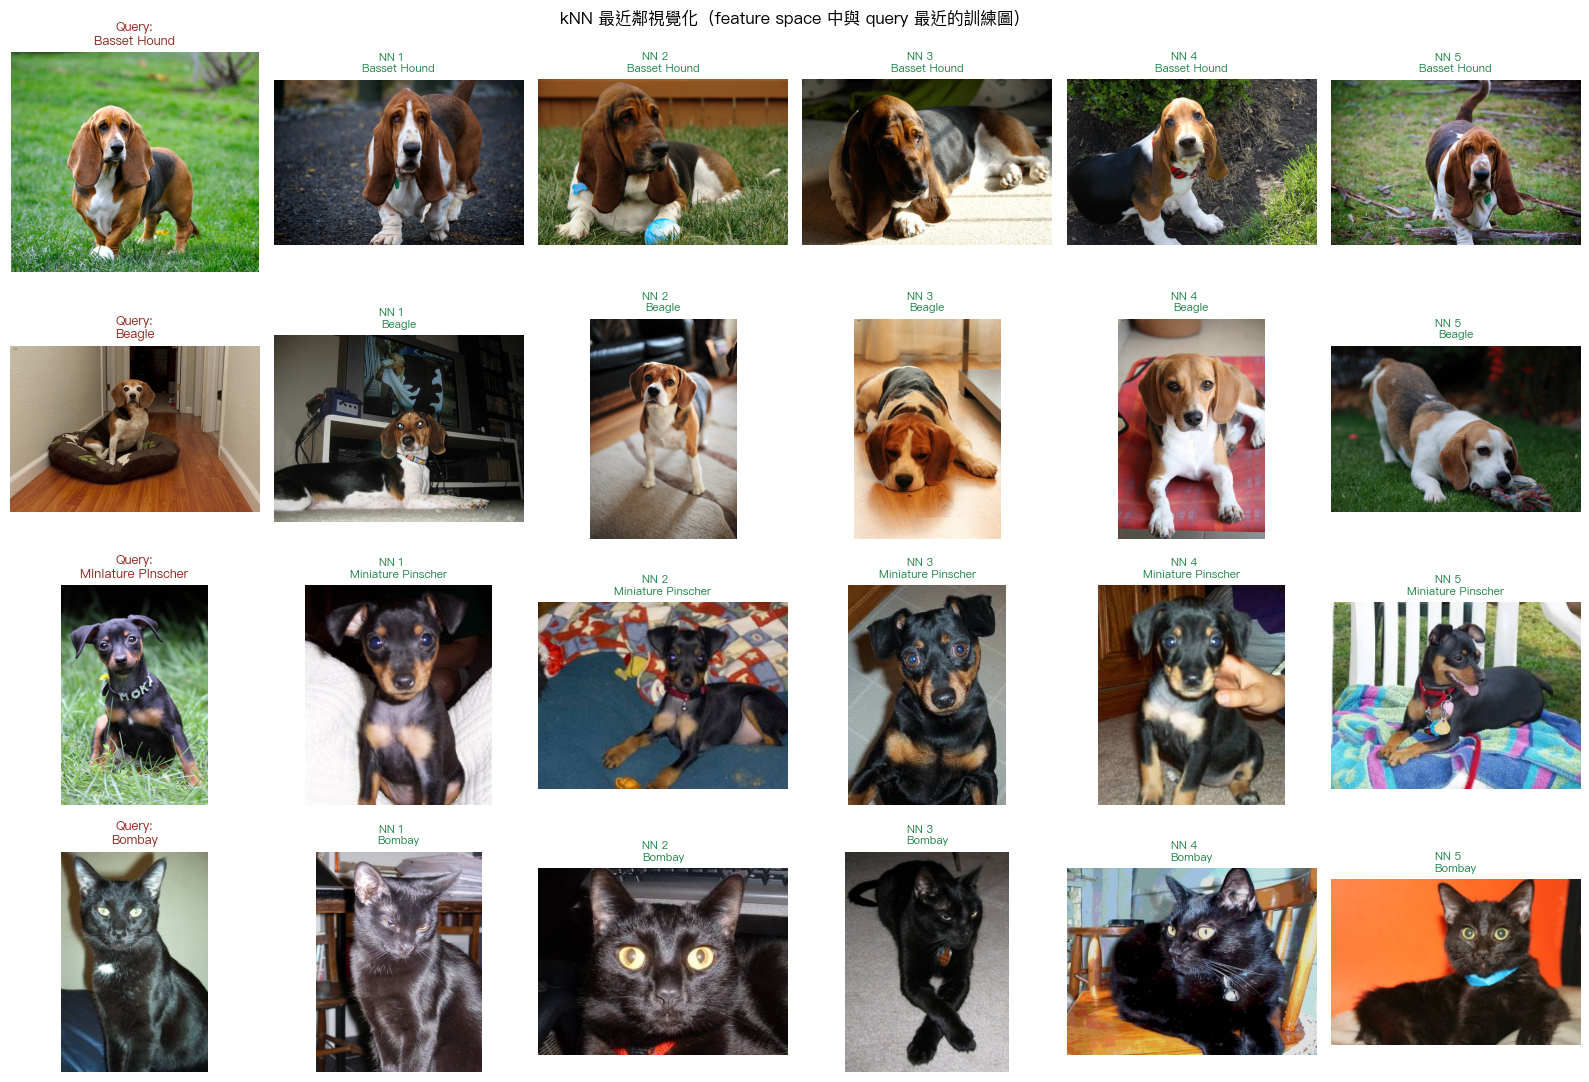

In [27]:
# 取幾張 query 影像，顯示其在 train set 中的 top-5 最近鄰
rng = np.random.RandomState(7)
query_idxs = rng.choice(len(test_ds), 4, replace=False)

# 用矩陣乘法找 nearest neighbor（cosine on normalized features）
q = torch.tensor(test_feats_n[query_idxs])
t = torch.tensor(train_feats_n)
sim = q @ t.T  # (4, N_train)
topk = sim.topk(5, dim=-1).indices.numpy()

vis_test  = OxfordIIITPet(root=DATA_ROOT, split='test',     download=False)
vis_train = OxfordIIITPet(root=DATA_ROOT, split='trainval', download=False)

fig, axes = plt.subplots(4, 6, figsize=(16, 11))
for row, qi in enumerate(query_idxs):
    qimg, qlbl = vis_test[qi]
    axes[row, 0].imshow(qimg)
    axes[row, 0].set_title(f'Query:\n{vis_test.classes[qlbl]}', fontsize=9, color='#922B21', fontweight='bold')
    axes[row, 0].axis('off')
    for col, ni in enumerate(topk[row]):
        nimg, nlbl = vis_train[ni]
        axes[row, col+1].imshow(nimg)
        match = '✓' if nlbl == qlbl else '✗'
        color = '#1E8449' if nlbl == qlbl else '#A93226'
        axes[row, col+1].set_title(f'NN {col+1} {match}\n{vis_train.classes[nlbl]}', fontsize=8, color=color)
        axes[row, col+1].axis('off')
plt.suptitle('kNN 最近鄰視覺化（feature space 中與 query 最近的訓練圖）', fontsize=12)
plt.tight_layout(); plt.show()

## 第 9 章：Linear Probe — SSL 領域的標準考試

**Linear Probe 協議**：凍結整個 backbone，**只訓練最後一層 `nn.Linear`** 把 feature 映射到類別。

為何這是標準？
- 把「feature 品質」和「fine-tune 能力」解耦——你考的就是 feature 本身好不好用
- 如果 features 真的線性可分，一層 linear 就夠
- DINO、SimCLR、MAE 全用這個指標——大家都用同一把尺，可橫向比較

### 我們已經提取好 features 了，所以 linear probe = 在 (N, 384) 矩陣上訓一個 logistic regression

In [29]:
from torch.utils.data import TensorDataset

# 不用 normalize 的 features（linear layer 自己會學 scale）
train_x = train_feats.to(DEVICE)
train_y = train_labels.to(DEVICE)
test_x  = test_feats.to(DEVICE)
test_y  = test_labels.to(DEVICE)

probe = nn.Linear(train_feats.shape[1], NUM_CLASSES).to(DEVICE)
optim_ = torch.optim.AdamW(probe.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 50
BATCH  = 128
N_train = train_x.size(0)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim_, T_max=EPOCHS)
history = {'train_loss': [], 'test_acc': []}

for epoch in range(EPOCHS):
    probe.train()
    perm = torch.randperm(N_train, device=DEVICE)
    losses = []
    for i in range(0, N_train, BATCH):
        idx = perm[i:i+BATCH]
        logits = probe(train_x[idx])
        loss = F.cross_entropy(logits, train_y[idx])
        optim_.zero_grad(); loss.backward(); optim_.step()
        losses.append(loss.item())
    scheduler.step()

    probe.eval()
    with torch.no_grad():
        test_preds = probe(test_x).argmax(dim=-1)
        test_acc = (test_preds == test_y).float().mean().item()
    history['train_loss'].append(np.mean(losses))
    history['test_acc'].append(test_acc)
    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:3d}  loss={np.mean(losses):.4f}  test_acc={test_acc*100:.2f}%')

probe_acc = history['test_acc'][-1]
print(f'\nFinal Linear Probe 測試準確率 / Test accuracy: {probe_acc*100:.2f}%')

Epoch   1  loss=1.8456  test_acc=89.21%
Epoch  10  loss=0.0824  test_acc=94.22%
Epoch  20  loss=0.0399  test_acc=94.36%
Epoch  30  loss=0.0272  test_acc=94.22%
Epoch  40  loss=0.0230  test_acc=94.28%
Epoch  50  loss=0.0224  test_acc=94.28%

Final Linear Probe 測試準確率 / Test accuracy: 94.28%


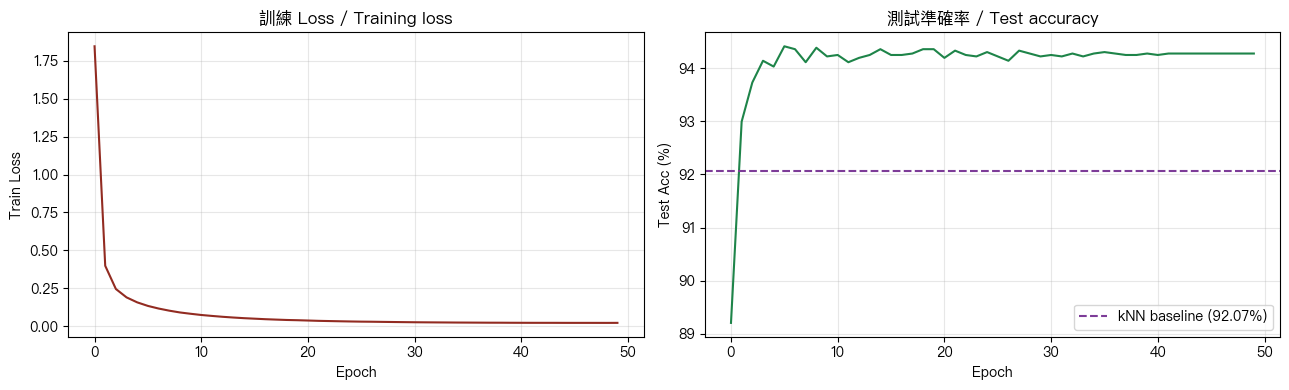

In [30]:
# 訓練曲線 / Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history['train_loss'], color='#922B21')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss')
axes[0].set_title('訓練 Loss / Training loss'); axes[0].grid(alpha=0.3)
axes[1].plot([a*100 for a in history['test_acc']], color='#1E8449')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Acc (%)')
axes[1].set_title('測試準確率 / Test accuracy'); axes[1].grid(alpha=0.3)
axes[1].axhline(knn_acc*100, color='#7D3C98', linestyle='--', label=f'kNN baseline ({knn_acc*100:.2f}%)')
axes[1].legend()
plt.tight_layout(); plt.show()

## 第 10 章：kNN vs Linear Probe 對比分析

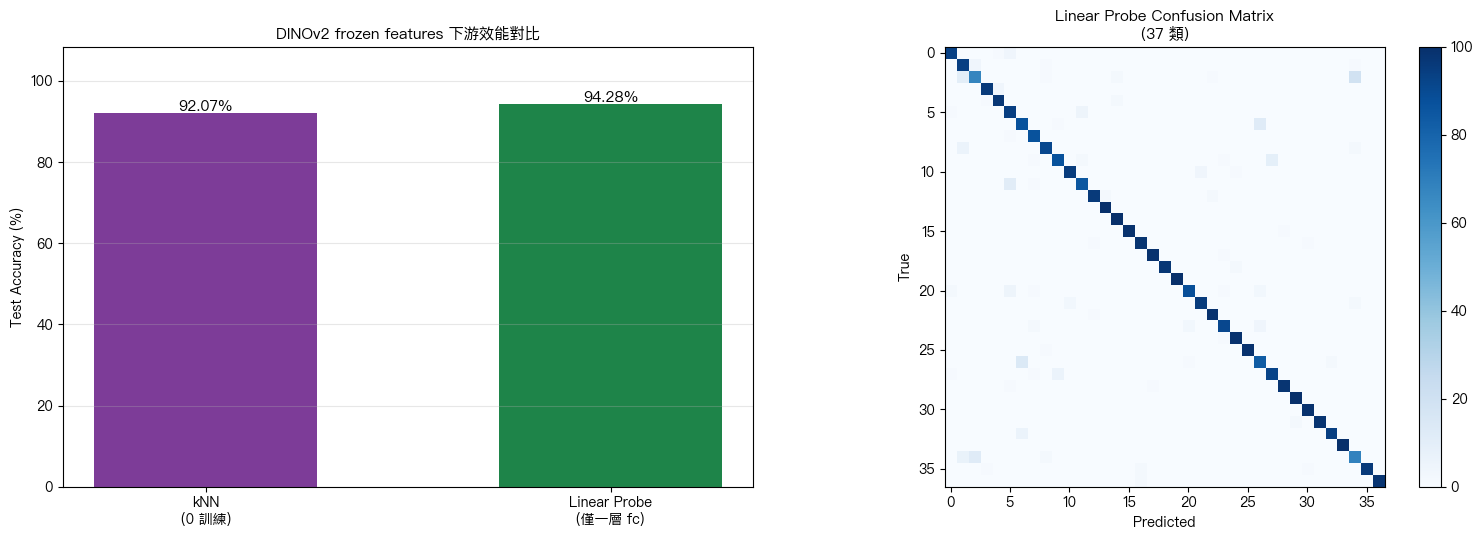

最常被混淆的 5 對類別 / Top-5 confused pairs:
  「American Pit Bull Terrier」  被預測成  「Staffordshire Bull Terrier」  (19 次)
  「Ragdoll」  被預測成  「Birman」  (14 次)
  「Birman」  被預測成  「Ragdoll」  (12 次)
  「Staffordshire Bull Terrier」  被預測成  「American Pit Bull Terrier」  (12 次)
  「Egyptian Mau」  被預測成  「Bengal」  (11 次)


In [31]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# 左：bar chart
methods = ['kNN\n(0 訓練)', 'Linear Probe\n(僅一層 fc)']
accs    = [knn_acc*100, probe_acc*100]
colors  = ['#7D3C98', '#1E8449']
bars = axes[0].bar(methods, accs, color=colors, width=0.55)
for b, a in zip(bars, accs):
    axes[0].text(b.get_x()+b.get_width()/2, a+0.5, f'{a:.2f}%',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_ylim(0, max(accs)*1.15)
axes[0].set_title('DINOv2 frozen features 下游效能對比', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# 右：linear probe 的 confusion matrix
with torch.no_grad():
    test_preds = probe(test_x).argmax(dim=-1).cpu().numpy()
cm = confusion_matrix(test_labels.numpy(), test_preds)
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title(f'Linear Probe Confusion Matrix\n({NUM_CLASSES} 類)', fontsize=11)
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

# 找出最常被混淆的類別 pair
np.fill_diagonal(cm, 0)
top_confusion = np.unravel_index(np.argsort(cm.ravel())[-5:][::-1], cm.shape)
print('最常被混淆的 5 對類別 / Top-5 confused pairs:')
for t, p in zip(*top_confusion):
    print(f'  「{train_ds.classes[t]}」  被預測成  「{train_ds.classes[p]}」  ({cm[t,p]} 次)')

### 對比 takeaway

- **kNN 已經很強**：完全沒訓練、靠 cosine 距離就拿到體面 accuracy → 直接證明 DINOv2 features 有強烈的「類別語意可分性」
- **Linear Probe 通常再多幾趴**：一層 linear 把 cosine 距離換成「學到的線性分界」，在邊界 case 上更精確
- **混淆模式有趣**：常常是視覺極相似的品種互混（例如 Egyptian Mau ↔ Bengal cat），說明 feature 確實在分「視覺差異」而不只是表面顏色

---
# Part IV — 視覺證據 / Evidence

> Part III 用數字證明 features 好。現在我們**用肉眼看見「為什麼好」**——回頭呼應 Part I 的直覺。

## 第 11 章：Attention Map 視覺化（DINO 招牌）

DINO 系列最令人驚艷的「湧現現象」：

> 沒有任何分割標註訓練，[CLS] token 對 patch tokens 的 attention 卻會**自動勾勒出物體輪廓**。

為什麼？回想 Part I 第 2 章：
- Student 看 local crop，要預測 teacher 看 global crop 的輸出
- 為了做到這件事，模型必須學會「從局部認出整體」
- → [CLS] token 必須**聚焦在主體物件上**，才能彙整足夠語意
- → attention map 自然強調主體

### 設定：用 518×518 高解析度跑

518 = 14 × 37 → 產生 37×37 = 1369 patches，attention map 更細緻。
`transformers` 透過 `interpolate_pos_encoding=True` 自動把 position embedding 插值到對應 grid。

In [32]:
ATTN_SIZE = 518
attn_transform = transforms.Compose([
    transforms.Resize((ATTN_SIZE, ATTN_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=DINO_MEAN, std=DINO_STD),
])

def get_attention_map(pil_img, model, device, layer=-1):
    """取最後一層、CLS 對所有 patch 的 attention（平均所有 heads 或保留分頭）。
    回傳: (heads, grid, grid) numpy array
    """
    x = attn_transform(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(pixel_values=x, output_attentions=True, interpolate_pos_encoding=True)
    attn = out.attentions[layer][0]  # (heads, N, N)
    n_reg = getattr(model.config, 'num_register_tokens', 0)
    patch_start = 1 + n_reg
    cls_to_patch = attn[:, 0, patch_start:]  # (heads, num_patches)
    n_patches = cls_to_patch.shape[-1]
    grid = int(n_patches ** 0.5)
    return cls_to_patch.reshape(-1, grid, grid).cpu().numpy()

# 拿一張寵物原圖
pet_img, pet_lbl = _vis_ds[0]
attn_heads = get_attention_map(pet_img, model, DEVICE)
print(f'attention map shape: {attn_heads.shape}  (heads, grid, grid)')

attention map shape: (6, 37, 37)  (heads, grid, grid)


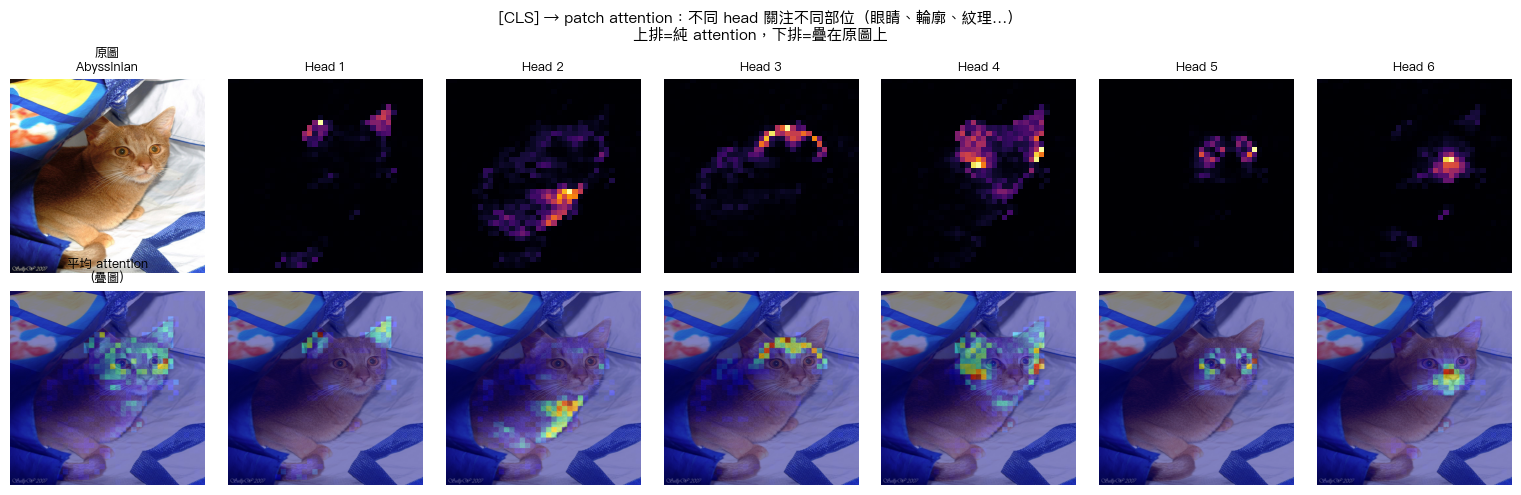

In [33]:
# 多頭視覺化 / Visualize attention per head
n_heads = attn_heads.shape[0]
fig, axes = plt.subplots(2, n_heads + 1, figsize=(2.2*(n_heads+1), 5))

# 第一欄：原圖 + 平均 attention overlay
axes[0,0].imshow(pet_img.resize((ATTN_SIZE, ATTN_SIZE)))
axes[0,0].set_title(f'原圖\n{_vis_ds.classes[pet_lbl]}', fontsize=9)
axes[0,0].axis('off')
mean_attn = attn_heads.mean(0)
axes[1,0].imshow(pet_img.resize((ATTN_SIZE, ATTN_SIZE)))
ax_overlay = axes[1,0].imshow(
    np.kron(mean_attn, np.ones((ATTN_SIZE//mean_attn.shape[0], ATTN_SIZE//mean_attn.shape[1]))),
    cmap='jet', alpha=0.5)
axes[1,0].set_title('平均 attention\n(疊圖)', fontsize=9)
axes[1,0].axis('off')

# 後面每欄：單一 head
for h in range(n_heads):
    axes[0, h+1].imshow(attn_heads[h], cmap='inferno')
    axes[0, h+1].set_title(f'Head {h+1}', fontsize=9)
    axes[0, h+1].axis('off')
    axes[1, h+1].imshow(pet_img.resize((ATTN_SIZE, ATTN_SIZE)))
    axes[1, h+1].imshow(
        np.kron(attn_heads[h], np.ones((ATTN_SIZE//attn_heads.shape[1], ATTN_SIZE//attn_heads.shape[2]))),
        cmap='jet', alpha=0.5)
    axes[1, h+1].axis('off')

plt.suptitle(
    '[CLS] → patch attention：不同 head 關注不同部位（眼睛、輪廓、紋理…）\n上排=純 attention，下排=疊在原圖上',
    fontsize=11)
plt.tight_layout(); plt.show()

**觀察：**
- 不同 head 學到關注不同的視覺特徵——眼鼻嘴、毛皮邊緣、身體輪廓——這就是 multi-head attention 「分工」的證據
- 整體 attention 在主體上集中，背景幾乎沒被關注
- **這完全是 emergent 行為**——沒有任何 segmentation 標註訓練過 DINO

## 第 12 章：有 / 無 Register Tokens 對比

回顧 Part I 第 3 章：DINOv2 原版（無 registers）的 attention map 有時候會出現**高激活雜訊點**。我們現在親自看。

步驟：
1. 載入無 registers 版的 `facebook/dinov2-small`
2. 對同一張寵物圖跑同一個 attention 抽取邏輯
3. 並排對比

In [34]:
MODEL_NAME_NOREG = 'facebook/dinov2-small'
# 同樣用 eager attention 以便拿 attention weights
model_noreg = AutoModel.from_pretrained(MODEL_NAME_NOREG, attn_implementation='eager').to(DEVICE).eval()
print(f'無 register 版: {MODEL_NAME_NOREG}')
print(f'  num_register_tokens = {getattr(model_noreg.config, "num_register_tokens", 0)}')

無 register 版: facebook/dinov2-small
  num_register_tokens = 0


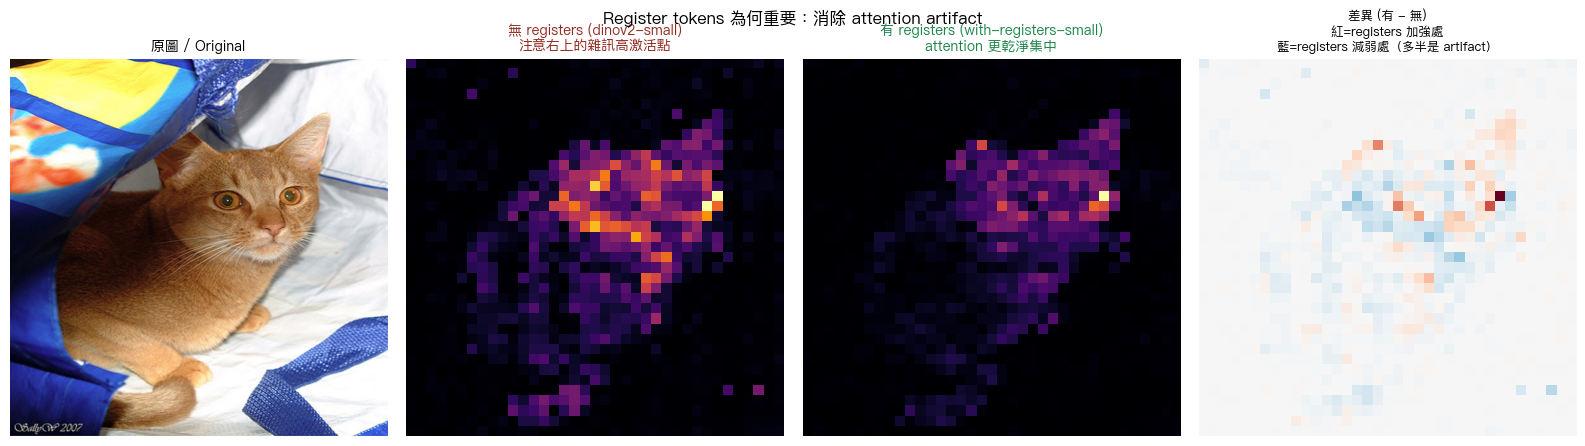

In [35]:
# 抽取兩個模型的 attention
attn_reg   = get_attention_map(pet_img, model,       DEVICE).mean(0)   # 平均所有 head
attn_noreg = get_attention_map(pet_img, model_noreg, DEVICE).mean(0)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
axes[0].imshow(pet_img.resize((ATTN_SIZE, ATTN_SIZE))); axes[0].set_title('原圖 / Original', fontsize=10); axes[0].axis('off')

axes[1].imshow(attn_noreg, cmap='inferno')
axes[1].set_title('無 registers (dinov2-small)\n注意右上的雜訊高激活點', fontsize=10, color='#922B21')
axes[1].axis('off')

axes[2].imshow(attn_reg, cmap='inferno')
axes[2].set_title('有 registers (with-registers-small)\nattention 更乾淨集中', fontsize=10, color='#1E8449')
axes[2].axis('off')

# 差異圖
diff = attn_reg - attn_noreg
axes[3].imshow(diff, cmap='RdBu_r', vmin=-abs(diff).max(), vmax=abs(diff).max())
axes[3].set_title('差異 (有 - 無)\n紅=registers 加強處\n藍=registers 減弱處（多半是 artifact）', fontsize=9)
axes[3].axis('off')

plt.suptitle('Register tokens 為何重要：消除 attention artifact', fontsize=12)
plt.tight_layout(); plt.show()

**觀察**（不同圖效果不同，可以多換幾張試試）：

- 無 register 版本常在背景區域出現幾個**不合理的亮點**——那就是「Vision Transformers Need Registers」論文指出的 artifact
- 有 register 版本 attention 更平滑、更聚焦在主體上
- 差異圖（最右）負值（藍色）多半出現在 artifact 位置——register tokens 把這些「計算暫存」吸走了

### 為什麼 artifact 會出現？

簡化解釋：
- ViT 在深層需要「全局計算暫存空間」（例如把整圖摘要傳給後續處理）
- 沒有 register 時，模型沒辦法，只能徵用某些不重要的 patch token 當暫存
- 那些 patch 的 attention 就被「污染」成異常高的值
- 加 register token = 給模型專門的 scratchpad → 不再徵用 patch tokens → attention 乾淨

---
# Part V — 收束 / Wrap-up

## 第 13 章：總結 + 延伸方向

### 我們完成了什麼

| Part | 內容 | 學到 |
|---|---|---|
| **I.** 直覺 | DINO 演算法、SSL motivation、v1→v3 演進 | **為什麼** DINO works |
| **II.** 解剖 | 載入 DINOv2、拆 token 結構、forward pass | 模型內部**長什麼樣** |
| **III.** 應用 | Feature extraction、kNN、Linear Probe、混淆分析 | DINOv2 features **多有用**（量化證據） |
| **IV.** 證據 | Multi-head attention、registers vs 無 registers | DINOv2 features **為什麼有用**（視覺證據） |

### 核心 Take-aways

1. **Pretrained > from scratch**：以 small models 對比，frozen DINOv2 + kNN 通常打敗從零訓練的 ViT。實務上 99% 場合用 pretrained 不要從零訓
2. **[CLS] token 不是萬靈丹**：對 image-level task 用 CLS、對 dense task 用 patch tokens、register tokens 別當 feature 用
3. **Attention map 不只是 debug 工具**：DINO 系列的 attention 直接可用於 unsupervised object discovery、video segmentation 等下游任務（LOST、TokenCut 等論文）
4. **Linear Probe 是 SSL 黃金標準**：當你看任何新的 SSL 方法 paper，第一個看的數字就是 ImageNet linear probe top-1

### 延伸方向

- **Fine-tune 整個 backbone**：解凍全部參數、用較低 LR（e.g. 1e-5）對特定資料集精修，準確率通常再多 1-3%。代價：需要 GPU、過擬合風險
- **LoRA / Adapter**：凍結 backbone，插入低秩 adapter（PEFT 框架），保留 generalization 又能微調
- **DINOv3**：2025 最新版，patch size 回到 16，加入 gated attention 與 Gram anchoring，效能再升一階
- **PCA 視覺化 patch features**：DINOv2 paper 經典圖——對 patch features 做 PCA，前 3 components 當 RGB 渲染。相同物體部位會被塗成同色、跨圖一致（unsupervised semantic correspondence）
- **下游 dense task**：拿 patch tokens（跳過 CLS 和 registers）接 segmentation head、depth estimation head
- **檢索系統**：把所有圖的 features cache 起來、用 cosine similarity 做圖像檢索

### 給自己的小練習

1. 把第 7 章的 `pool_strategy` 改成 `'mean_patch'` 或 `'cls_mean'`，看 kNN / linear probe 準確率怎麼變
2. 把 ATTN_SIZE 從 518 改成 224 或 980，比較 attention map 細緻度
3. 載入 `facebook/dinov2-with-registers-base`，比較和 small 的差異
4. 拿一張**非寵物**的圖（風景、產品、人臉）跑 attention map——還會找到主體嗎？